# MaxEnt Modelling
Workflow for fossil screening, MaxEnt calibration and evaluation, palaeoclimate projections, MESS analysis, and habitat-suitability statistics.

**Requirements.** Run this notebook from the project root using an ArcGIS Pro Python environment with ArcPy and the Spatial Analyst extension. Java and `maxent.jar` are required for MaxEnt; `xlrd` and `openpyxl` are required for the fossil workbooks.

Run **Configuration and common setup** first. Each subsequent major analysis section can then be rerun independently using section-specific variables and existing files on disk.

## Configuration and common setup

In [2]:
import os
import re
import subprocess
import time
from datetime import datetime

import arcpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

arcpy.env.overwriteOutput = True
arcpy.env.addOutputsToMap = False

project_dir = os.path.abspath(os.getcwd())
maxent_jar = os.path.join(project_dir, 'maxent.jar')

def relative_path(path):
    absolute_path = os.path.abspath(path)
    try:
        relative = os.path.relpath(absolute_path, project_dir)
    except ValueError:
        relative = os.path.basename(absolute_path)
    return relative.replace('\\', '/')

data_dir = os.path.join(project_dir, 'data')
paleoenvironment_dir = os.path.join(data_dir, 'paleoenvironment')
model_predictors_dir = os.path.join(paleoenvironment_dir, 'model_predictors')
predictor_selection_dir = os.path.join(paleoenvironment_dir, 'predictor_selection')
fossils_dir = os.path.join(data_dir, 'fossils')
aoi_dir = os.path.join(data_dir, 'aoi')
study_regions_dir = os.path.join(data_dir, 'study_regions')
output_dir = os.path.join(project_dir, 'output')

arcpy.CheckOutExtension('Spatial')
os.makedirs(output_dir, exist_ok=True)

# Input palaeoenvironmental rasters on the native 3.75° × 2.5° model grid.
PALEOCLIMATE_MODELS = {
    'xozzc': {'scenario_no':  1, 'name': 'Pliocene_Warm summer orbit',    'settings': '400 ppm CO<SUB>2</SUB>/Warm summer Orbit'},
    'xozzb': {'scenario_no':  2, 'name': 'Pliocene_Standard',            'settings': '400 ppm CO<SUB>2</SUB>/Modern Orbit'},
    'xozzf': {'scenario_no':  3, 'name': 'Pliocene_Warm winter orbit',   'settings': '400 ppm CO<SUB>2</SUB>/Warm winter Orbit'},
    'tenvl': {'scenario_no':  4, 'name': 'Pliocene_High CO<SUB>2</SUB>', 'settings': '450 ppm CO<SUB>2</SUB>/Modern Orbit'},
    'tenvk': {'scenario_no':  5, 'name': 'Pliocene_Low CO<SUB>2</SUB>',  'settings': '350 ppm CO<SUB>2</SUB>/Modern Orbit'},
    'tenvm': {'scenario_no':  6, 'name': 'Pliocene_PI CO<SUB>2</SUB>',   'settings': '280 ppm CO<SUB>2</SUB>/Modern Orbit'},
    'tdlvb': {'scenario_no':  7, 'name': 'Early Pleistocene Glacial_PI CO<SUB>2</SUB>',  'settings': '280 ppm CO<SUB>2</SUB>/M2 Orbit/Medium ice'},
    'tdlvd1': {'scenario_no': 8, 'name': 'Early Pleistocene Glacial_PI CO<SUB>2</SUB>',  'settings': '280 ppm CO<SUB>2</SUB>/M2 Orbit/Large ice'},
    'tdlvc': {'scenario_no':  9, 'name': 'Early Pleistocene Glacial_Low CO<SUB>2</SUB>', 'settings': '220 ppm CO<SUB>2</SUB>/M2 Orbit/Medium ice'},
    'tdlve': {'scenario_no': 10, 'name': 'Early Pleistocene Glacial_Low CO<SUB>2</SUB>', 'settings': '220 ppm CO<SUB>2</SUB>/M2 Orbit/Large ice'},
    'xqlne': {'scenario_no': 11, 'name': 'Early Pleistocene Glacial_Low CO<SUB>2</SUB>', 'settings': '220 ppm CO<SUB>2</SUB>/Modern Orbit/Medium ice'},
    'xqlnf': {'scenario_no': 12, 'name': 'Early Pleistocene Glacial_Low CO<SUB>2</SUB>', 'settings': '220 ppm CO<SUB>2</SUB>/Orbit with low NHSI/Medium ice'},
    'xnzib': {'scenario_no': 13, 'name': 'Late Pleistocene Glacial', 'settings': '180 ppm CO<SUB>2</SUB>/LGM Orbit/Standard ice'},
    'xnziw': {'scenario_no': 14, 'name': 'Late Pleistocene Glacial', 'settings': '180 ppm CO<SUB>2</SUB>/LGM Orbit/Medium ice'},
    'xnzix': {'scenario_no': 15, 'name': 'Late Pleistocene Glacial', 'settings': '180 ppm CO<SUB>2</SUB>/LGM Orbit/Large ice'},
}
PALEOCLIMATE_MODEL_CODES = list(PALEOCLIMATE_MODELS)
PALEOCLIMATE_MODEL_GROUPS = {
    'Pliocene': ['xozzb', 'xozzc', 'xozzf', 'tenvl', 'tenvk', 'tenvm'],
    'EarlyPleistoceneGlacial': ['xqlne', 'tdlvb', 'tdlvc', 'tdlvd1', 'tdlve', 'xqlnf'],
    'LatePleistoceneGlacial': ['xnzib', 'xnziw', 'xnzix'],
}

print(f'Configuration loaded: {len(PALEOCLIMATE_MODEL_CODES)} palaeoclimate scenarios.')
print(f'{datetime.now():%Y-%m-%d %H:%M:%S}')


Configuration loaded: 15 palaeoclimate scenarios.
2026-08-31 00:07:47


In [3]:
# Final predictors used by the MaxEnt model.
PREDICTORS = ['biome', 'temp_annual_mean', 'precip_annual_total']
PROJECTION_MODEL_CODES = PALEOCLIMATE_MODEL_CODES.copy()
TRAINING_MODEL_CODE = 'xnzib'
AGE_MIN, AGE_MAX = 20000, 22000
# AGE_MIN, AGE_MAX = 19000, 26500  # temporal-sensitivity run
AOI_NAME = 'Eurasia'
aoi_shp = os.path.join(aoi_dir, 'Eurasia.shp')

# Cross-validation evaluates model performance; the final model uses all unique training grid cells.
MAXENT_CV_FOLDS = 3
MAXENT_BETA_MULTIPLIER = 1
MAXENT_MAX_BACKGROUND = 20000
MAXENT_MAX_ITERATIONS = 500
MAXENT_CONVERGENCE_THRESHOLD = 1e-5
MAXENT_DEFAULT_PREVALENCE = 0.5
MAXENT_OUTPUT_FORMAT = 'Cloglog'
FEATURE_CLASSES, USE_LINEAR_FEATURE, USE_QUADRATIC_FEATURE, USE_HINGE_FEATURE, USE_PRODUCT_FEATURE = 'LQ', True, True, False, False
USE_THRESHOLD_FEATURE = False

MAXENT_BASE_ARGS = (
    'warnings=false',
    'visible=false',
    'removeduplicates=false',
    f'outputformat={MAXENT_OUTPUT_FORMAT}',
    f'betamultiplier={MAXENT_BETA_MULTIPLIER}',
    f'maximumbackground={MAXENT_MAX_BACKGROUND}',
    f'maximumiterations={MAXENT_MAX_ITERATIONS}',
    f'convergencethreshold={MAXENT_CONVERGENCE_THRESHOLD}',
    f'defaultprevalence={MAXENT_DEFAULT_PREVALENCE}',
    'randomseed=false',
    'randomtestpoints=0',
    'extrapolate=true',
    'doclamp=true',
    'writeclampgrid=true',
    'redoifexists',
    'autorun'
)

MAIN_FEATURE_ARGS = (
    'autofeature=false',
    f'linear={str(USE_LINEAR_FEATURE).lower()}',
    f'quadratic={str(USE_QUADRATIC_FEATURE).lower()}',
    f'hinge={str(USE_HINGE_FEATURE).lower()}',
    f'product={str(USE_PRODUCT_FEATURE).lower()}',
    f'threshold={str(USE_THRESHOLD_FEATURE).lower()}'
)

maxent_run_name = f'{AGE_MIN}-{AGE_MAX}_{AOI_NAME}'
maxent_run_dir = os.path.join(output_dir, maxent_run_name)
maxent_input_dir = os.path.join(maxent_run_dir, 'input')
maxent_output_dir = os.path.join(maxent_run_dir, 'results')
maxent_cv_dir = os.path.join(maxent_output_dir, f'CV_{MAXENT_CV_FOLDS}fold')
maxent_output_stats_dir = os.path.join(maxent_output_dir, 'Stats')
mess_dir = os.path.join(maxent_output_dir, 'MESS')
for folder in [maxent_input_dir, maxent_output_dir, maxent_cv_dir, maxent_output_stats_dir, mess_dir]:
    os.makedirs(folder, exist_ok=True)

def predictor_tif_path(predictor, model_code):
    main_path = os.path.join(model_predictors_dir, f'{predictor}_{model_code}.tif')
    if os.path.exists(main_path):
        return main_path
    return os.path.join(predictor_selection_dir, f'{predictor}_{model_code}.tif')

configured_predictor_layers = PREDICTORS.copy()
categorical_predictor_layers = [layer for layer in configured_predictor_layers if layer == 'biome']
print(f'MaxEnt predictors: {configured_predictor_layers}')
print(f"Categorical predictors: {categorical_predictor_layers or 'None'}")


grid_template_tif = predictor_tif_path(PREDICTORS[0], TRAINING_MODEL_CODE)
if not arcpy.Exists(grid_template_tif):
    raise FileNotFoundError(f'Missing template predictor raster: {relative_path(grid_template_tif)}')
grid_template = arcpy.Raster(grid_template_tif)
xmin, xmax, ymin, ymax = grid_template.extent.XMin, grid_template.extent.XMax, grid_template.extent.YMin, grid_template.extent.YMax
xres, yres, ncols, nrows = grid_template.meanCellWidth, grid_template.meanCellHeight, grid_template.width, grid_template.height

def validate_grid_against_template(raster):
    r = arcpy.Raster(raster)
    raster_sr, template_sr = arcpy.Describe(raster).spatialReference, arcpy.Describe(grid_template_tif).spatialReference
    same_crs = ((raster_sr.factoryCode not in [0, None]) and raster_sr.factoryCode == template_sr.factoryCode) or raster_sr.exportToString() == template_sr.exportToString()
    same_grid = (np.isclose(r.meanCellWidth, xres) and np.isclose(r.meanCellHeight, yres) and r.width == ncols and r.height == nrows and
                 np.isclose(r.extent.XMin, xmin) and np.isclose(r.extent.XMax, xmax) and np.isclose(r.extent.YMin, ymin) and np.isclose(r.extent.YMax, ymax))
    if not (same_grid and same_crs):
        raise ValueError(f'Grid/CRS mismatch: {relative_path(raster)}')

# Fossil inputs and derived MaxEnt files.
fossils_xls = os.path.join(fossils_dir, 'Fossils.xls')
fossils_marked_xlsx = os.path.join(maxent_input_dir, f'Fossils_marked_{AGE_MIN}-{AGE_MAX}.xlsx')
filter_suffix = f'{AGE_MIN}-{AGE_MAX}_{AOI_NAME}'
fossil_occurrences_csv = os.path.join(maxent_input_dir, f'Fossil_occurrences_{filter_suffix}.csv')
fossil_occurrences_shp = os.path.join(maxent_input_dir, f'Fossil_occurrences_{filter_suffix}.shp')
fossil_grids_shp = os.path.join(maxent_input_dir, f'Fossil_grids_{filter_suffix}.shp')
fossil_grids_csv = os.path.join(maxent_input_dir, f'Fossil_grids_{filter_suffix}.csv')
full_background_csv = os.path.join(maxent_input_dir, f'full_background_{TRAINING_MODEL_CODE}.csv')
aoi_grids_shp = os.path.join(maxent_input_dir, f'{AOI_NAME}_grids.shp')


MaxEnt predictors: ['biome', 'temp_annual_mean', 'precip_annual_total']
Categorical predictors: ['biome']


### AOI grid preparation


In [4]:
start_time = time.time()

# Persist the AOI grid for reuse in fossil, projection, and regional analyses.
# Store derived grid shapefiles in the native template coordinate system.

def create_grid_polygon(row, col):
    x0, x1 = xmin + col * xres, xmin + (col + 1) * xres
    y0, y1 = ymax - (row + 1) * yres, ymax - row * yres
    return arcpy.Polygon(arcpy.Array([arcpy.Point(x0, y0), arcpy.Point(x0, y1), arcpy.Point(x1, y1), arcpy.Point(x1, y0), arcpy.Point(x0, y0)]))

def get_shapefile_field_names(columns, output_shp):
    workspace, used, names = os.path.dirname(output_shp), {'ROW', 'COL'}, {}
    for column in columns:
        candidate = arcpy.ValidateFieldName(str(column), workspace)
        base, i = candidate, 1
        while candidate.upper() in used:
            suffix = str(i)
            candidate = arcpy.ValidateFieldName(f'{base[:max(1, 10-len(suffix))]}{suffix}', workspace)
            i += 1
        used.add(candidate.upper())
        names[column] = candidate
    return names

def add_dataframe_fields(output_shp, dataframe, columns):
    names = get_shapefile_field_names(columns, output_shp)
    for column in columns:
        series = dataframe[column]
        if pd.api.types.is_integer_dtype(series.dtype):
            arcpy.management.AddField(output_shp, names[column], 'LONG')
        elif pd.api.types.is_numeric_dtype(series.dtype):
            arcpy.management.AddField(output_shp, names[column], 'DOUBLE')
        else:
            arcpy.management.AddField(output_shp, names[column], 'TEXT', field_length=255)
    return names

def to_cursor_value(value):
    if pd.isna(value):
        return None
    return value.item() if isinstance(value, np.generic) else value

def write_grid_shapefile(dataframe, output_shp):
    data = dataframe.copy()
    if 'ROW' not in data.columns or 'COL' not in data.columns:
        data['ROW'] = np.rint((ymax - yres / 2 - pd.to_numeric(data['latitude'])) / yres).astype(int)
        data['COL'] = np.rint((pd.to_numeric(data['longitude']) - xmin - xres / 2) / xres).astype(int)
    if data.duplicated(['ROW', 'COL']).any():
        raise ValueError(f'Duplicate grid cells: {relative_path(output_shp)}')
    if not (((data['ROW'] >= 0) & (data['ROW'] < nrows) & (data['COL'] >= 0) & (data['COL'] < ncols)).all()):
        raise ValueError(f'Grid index outside template: {relative_path(output_shp)}')
    if arcpy.Exists(output_shp):
        arcpy.management.Delete(output_shp)
    with arcpy.EnvManager(outputCoordinateSystem=None):
        arcpy.management.CreateFeatureclass(os.path.dirname(output_shp), os.path.basename(output_shp), 'POLYGON')
    arcpy.management.AddField(output_shp, 'ROW', 'LONG')
    arcpy.management.AddField(output_shp, 'COL', 'LONG')
    attribute_columns = [c for c in data.columns if c not in ['ROW', 'COL']]
    field_names = add_dataframe_fields(output_shp, data, attribute_columns)
    cursor_fields = ['SHAPE@', 'ROW', 'COL'] + [field_names[c] for c in attribute_columns]
    with arcpy.da.InsertCursor(output_shp, cursor_fields) as cursor:
        for _, record in data.iterrows():
            row, col = int(record['ROW']), int(record['COL'])
            cursor.insertRow([create_grid_polygon(row, col), row, col] + [to_cursor_value(record[c]) for c in attribute_columns])
    arcpy.management.DefineProjection(output_shp, grid_template.spatialReference)
    return len(data)

def write_occurrence_shapefile(dataframe, output_shp):
    data = dataframe.copy()
    if arcpy.Exists(output_shp):
        arcpy.management.Delete(output_shp)
    with arcpy.EnvManager(outputCoordinateSystem=None):
        arcpy.management.CreateFeatureclass(os.path.dirname(output_shp), os.path.basename(output_shp), 'POINT')
    arcpy.management.AddField(output_shp, 'ROW', 'LONG')
    arcpy.management.AddField(output_shp, 'COL', 'LONG')
    attribute_columns = [c for c in data.columns if c not in ['ROW', 'COL']]
    field_names = add_dataframe_fields(output_shp, data, attribute_columns)
    cursor_fields = ['SHAPE@', 'ROW', 'COL'] + [field_names[c] for c in attribute_columns]
    with arcpy.da.InsertCursor(output_shp, cursor_fields) as cursor:
        for _, record in data.iterrows():
            point = arcpy.Point(float(record['ConvLon']), float(record['ConvLat']))
            cursor.insertRow([point, int(record['ROW']), int(record['COL'])] + [to_cursor_value(record[c]) for c in attribute_columns])
    arcpy.management.DefineProjection(output_shp, grid_template.spatialReference)
    return len(data)

selected_cells = set()
aoi_fc = os.path.join(arcpy.env.scratchGDB, 'maxent_aoi')
fishnet = os.path.join(arcpy.env.scratchGDB, 'maxent_aoi_grid')
fishnet_test = os.path.join(arcpy.env.scratchGDB, 'maxent_aoi_grid_test')
intersect = os.path.join(arcpy.env.scratchGDB, 'maxent_aoi_intersect')
for fc in [aoi_fc, fishnet, fishnet_test, intersect]:
    if arcpy.Exists(fc):
        arcpy.management.Delete(fc)

arcpy.management.Project(aoi_shp, aoi_fc, grid_template.spatialReference)
aoi_ext = arcpy.Describe(aoi_fc).extent

# Create candidate native-grid cells across the AOI latitude range before spatial intersection with the calibration AOI.
b0 = max(0, int(np.floor((aoi_ext.YMin - ymin) / yres)))
b1 = min(nrows, int(np.ceil((aoi_ext.YMax - ymin) / yres)))
left, bottom = xmin, ymin + b0 * yres
with arcpy.EnvManager(outputCoordinateSystem=None):
    arcpy.management.CreateFishnet(fishnet, f'{left} {bottom}', f'{left} {bottom + yres}', xres, yres, b1 - b0, ncols, '#', 'NO_LABELS', '#', 'POLYGON')
arcpy.management.AddField(fishnet, 'ROW', 'LONG')
arcpy.management.AddField(fishnet, 'COL', 'LONG')
with arcpy.da.UpdateCursor(fishnet, ['SHAPE@', 'ROW', 'COL']) as cursor:
    for shape, row, col in cursor:
        p = shape.centroid
        cursor.updateRow((shape, int(np.rint((ymax - yres / 2 - p.Y) / yres)), int(np.rint((p.X - xmin - xres / 2) / xres))))

# Normalize a temporary copy of the candidate grid to the AOI's [-180, 180] longitude domain for spatial intersection.
test_sr = arcpy.Describe(aoi_fc).spatialReference
arcpy.management.CreateFeatureclass(arcpy.env.scratchGDB, 'maxent_aoi_grid_test', 'POLYGON', fishnet, spatial_reference=test_sr)

def create_rectangle(x0, y0, x1, y1):
    y0, y1 = max(y0, -90), min(y1, 90)
    return arcpy.Polygon(arcpy.Array([arcpy.Point(x0, y0), arcpy.Point(x0, y1), arcpy.Point(x1, y1), arcpy.Point(x1, y0), arcpy.Point(x0, y0)]), test_sr)

with arcpy.da.SearchCursor(fishnet, ['SHAPE@', 'ROW', 'COL']) as src_cursor, arcpy.da.InsertCursor(fishnet_test, ['SHAPE@', 'ROW', 'COL']) as dst_cursor:
    for shape, row, col in src_cursor:
        e, cx = shape.extent, shape.centroid.X
        if np.isclose(cx, 180):
            dst_cursor.insertRow([create_rectangle(e.XMin, e.YMin, 180, e.YMax), row, col])
            dst_cursor.insertRow([create_rectangle(-180, e.YMin, e.XMax - 360, e.YMax), row, col])
        elif cx > 180:
            dst_cursor.insertRow([create_rectangle(e.XMin - 360, e.YMin, e.XMax - 360, e.YMax), row, col])
        else:
            dst_cursor.insertRow([create_rectangle(e.XMin, e.YMin, e.XMax, e.YMax), row, col])

arcpy.analysis.Intersect([fishnet_test, aoi_fc], intersect)
with arcpy.da.SearchCursor(intersect, ['ROW', 'COL']) as cursor:
    selected_cells.update((row, col) for row, col in cursor)
for fc in [aoi_fc, fishnet, fishnet_test, intersect]:
    if arcpy.Exists(fc):
        arcpy.management.Delete(fc)

aoi_cells = pd.DataFrame(sorted(selected_cells), columns=['ROW', 'COL'])
write_grid_shapefile(aoi_cells, aoi_grids_shp)
print(f'AOI: {AOI_NAME} | selected cells: {len(selected_cells):,}')
print(f'AOI grid: {relative_path(aoi_grids_shp)}')
print(f'{datetime.now():%Y-%m-%d %H:%M:%S}      Runtime: {time.time() - start_time:.2f} seconds')


AOI: Eurasia | selected cells: 1,074
AOI grid: output/20000-22000_Eurasia/input/Eurasia_grids.shp
2026-08-31 00:08:06      Runtime: 19.20 seconds


In [5]:
def convert_csv_to_tif(projection_csv, template_tif, output_tif, nodata=-9999.0):
    grid_template = arcpy.Raster(template_tif)
    xmin, ymin, ymax = grid_template.extent.XMin, grid_template.extent.YMin, grid_template.extent.YMax
    xres, yres = grid_template.meanCellWidth, grid_template.meanCellHeight
    ncols, nrows = grid_template.width, grid_template.height

    pred = pd.read_csv(projection_csv)

    # MaxEnt SWD projection output: X and Y are the first two columns; prediction is the final column.
    x = pd.to_numeric(pred.iloc[:, 0], errors='coerce').to_numpy()
    y = pd.to_numeric(pred.iloc[:, 1], errors='coerce').to_numpy()
    value = pd.to_numeric(pred.iloc[:, -1], errors='coerce').to_numpy()

    cols = np.rint((x - xmin - xres / 2) / xres).astype(np.int64)
    rows = np.rint((ymax - yres / 2 - y) / yres).astype(np.int64)

    valid = np.isfinite(value) & (cols >= 0) & (cols < ncols) & (rows >= 0) & (rows < nrows)

    arr = np.full((nrows, ncols), nodata, dtype=np.float32)
    arr[rows[valid], cols[valid]] = value[valid].astype(np.float32)

    raster = arcpy.NumPyArrayToRaster(arr, arcpy.Point(xmin, ymin), xres, yres, nodata)
    raster.save(output_tif)
    arcpy.management.DefineProjection(output_tif, grid_template.spatialReference)

    print(
        f'[OK] {os.path.basename(output_tif)} | '
        f'{ncols}×{nrows} | {xres:g}×{yres:g} | '
        f'{valid.sum():,} cells'
    )


## Fossil records

Keep=Yes; calibrated 95.4% age range overlaps the target interval; eligible records are deduplicated by valid Lab No; records without a valid Lab No are retained with a manual-review warning; coordinates, AOI and predictor values are validated; final MaxEnt occurrences are deduplicated by ROW/COL.


In [6]:
start_time = time.time()

def parse_numeric(s):
    out = pd.to_numeric(s, errors='coerce')
    missing = out.isna() & s.notna()
    if missing.any():
        text = (
            s.loc[missing]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('±', '', regex=False)
            .str.replace('−', '-', regex=False)
            .str.extract(r'([-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?)', expand=False)
        )
        out.loc[missing] = pd.to_numeric(text, errors='coerce')
    return out

def parse_calibrated_range(s):
    """Parse a reported 95.4% calibrated-age range and return its younger and older bounds."""
    text = s.astype('string').str.replace(',', '', regex=False).str.replace('−', '-', regex=False).str.replace('–', '-', regex=False).str.replace('—', '-', regex=False).str.strip()
    parts = text.str.extract(r'^\s*(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)\s*$')
    first = pd.to_numeric(parts[0], errors='coerce')
    second = pd.to_numeric(parts[1], errors='coerce')
    valid = first.notna() & second.notna()
    age_young = pd.Series(np.nan, index=s.index, dtype=float)
    age_old = pd.Series(np.nan, index=s.index, dtype=float)
    age_young.loc[valid] = np.minimum(first.loc[valid], second.loc[valid])
    age_old.loc[valid] = np.maximum(first.loc[valid], second.loc[valid])
    return age_young, age_old

def calibrated_interval(df, cfg):
    """Return the calibrated-age interval and provenance defined for a worksheet."""
    method = pd.Series('', index=df.index, dtype=object)
    data_rows = df.index[cfg['data_start']:]
    if cfg['range_mode'] == 'mean_sigma':
        center = parse_numeric(df.iloc[:, cfg['age']])
        sigma = parse_numeric(df.iloc[:, cfg['error']]).abs()
        multiplier = cfg['sigma_multiplier']
        age_young = center - multiplier * sigma
        age_old = center + multiplier * sigma
        method.loc[data_rows] = f"{cfg['age_label']} ± {multiplier:g}×{cfg['error_label']} (approx. 95.4%)"
    elif cfg['range_mode'] == 'reported_95_4':
        age_young, age_old = parse_calibrated_range(df.iloc[:, cfg['range_col']])
        method.loc[data_rows] = cfg['range_label']
    else:
        raise ValueError(f"Unsupported range_mode: {cfg['range_mode']}")
    return age_young, age_old, method

def normalize_longitude(lon):
    lon = pd.to_numeric(lon, errors='coerce')
    return ((lon - xmin) % 360) + xmin

def parse_lab_ids(value):
    if pd.isna(value):
        return []
    text = str(value).upper().replace('−', '-').replace('–', '-').replace('—', '-').strip()
    if text in ['', 'NA', 'N/A', 'NONE', 'NAN', '-']:
        return []

    lab_ids = []
    pattern = r'(?<![A-Z0-9])([A-Z][A-Z0-9]*)\s*-\s*(\d+[A-Z]?)(?P<short>(?:\s*/\s*\d+[A-Z]?)*)'
    for match in re.finditer(pattern, text):
        prefix, number = match.group(1), match.group(2)
        lab_ids.append(f'{prefix}-{number}')
        lab_ids.extend(f'{prefix}-{suffix}' for suffix in re.findall(r'/\s*(\d+[A-Z]?)', match.group('short')))

    return list(dict.fromkeys(lab_ids))

def coordinate_relation(lon1, lat1, lon2, lat2):
    if not all(pd.notna(v) for v in [lon1, lat1, lon2, lat2]):
        return 'coordinates unavailable'
    if np.isclose(lon1, lon2) and np.isclose(lat1, lat2):
        return 'same coordinates'
    return 'similar coordinates' if abs(lon1 - lon2) <= 0.5 and abs(lat1 - lat2) <= 0.5 else 'different coordinates'

# Age-screening rules:
# Fordham: OxCal_age ± 2 × OxCal_error (approximate 95.4% interval).
# Puzachenko: reported IntCal20 95.4% calibrated-age range.
# Cheng: reported 95.4% calibrated-age range.
sheet_configs = {
    'Fordham': {'range_mode': 'mean_sigma', 'age': 10, 'error': 11, 'sigma_multiplier': 2.0, 'age_label': 'OxCal_age', 'error_label': 'OxCal_error', 'data_start': 1, 'keep_col': 25, 'keep_value': 'YES', 'lon': 6, 'lat': 5, 'lab': 7},
    'Puzachenko': {'range_mode': 'reported_95_4', 'range_col': 12, 'range_label': 'IntCal20 reported 95.4% range', 'data_start': 3, 'keep_col': 15, 'keep_value': 'YES', 'lon': 3, 'lat': 2, 'lab': 13},
    'Cheng': {'range_mode': 'reported_95_4', 'range_col': 6, 'range_label': 'IntCal20 calibrated 95.4% range', 'data_start': 2, 'keep_col': 9, 'keep_value': 'YES', 'lon': 1, 'lat': 2, 'lab': 7}
}

xls = pd.ExcelFile(fossils_xls, engine='xlrd')
missing_sheets = [sheet_name for sheet_name in sheet_configs if sheet_name not in xls.sheet_names]
if missing_sheets:
    raise ValueError(f'Missing fossil worksheets: {missing_sheets}; available worksheets: {xls.sheet_names}')
raw_sheets = {sheet_name: pd.read_excel(xls, sheet_name=sheet_name, header=None, dtype=object) for sheet_name in sheet_configs}

# For Fordham records sharing a Lab No with Puzachenko or Cheng, use the reported 95.4% range instead of the Fordham approximation.
# For duplicate Lab Nos, retain the first eligible record in the order Fordham → Puzachenko → Cheng.
exact_ranges_by_lab = {}
for exact_sheet in ['Puzachenko', 'Cheng']:
    cfg = sheet_configs[exact_sheet]
    df = raw_sheets[exact_sheet]
    age_young, age_old, _ = calibrated_interval(df, cfg)
    keep_match = df.iloc[:, cfg['keep_col']].astype(str).str.strip().str.upper().eq(cfg['keep_value'])
    for idx in df.index[cfg['data_start']:]:
        if not (keep_match.loc[idx] and pd.notna(age_young.loc[idx]) and pd.notna(age_old.loc[idx])):
            continue
        for lab_id in parse_lab_ids(df.iat[idx, cfg['lab']]):
            candidate = {'young': float(age_young.loc[idx]), 'old': float(age_old.loc[idx]), 'sheet': exact_sheet, 'row': idx + 1}
            if lab_id in exact_ranges_by_lab:
                previous = exact_ranges_by_lab[lab_id]
                same_range = np.isclose(previous['young'], candidate['young']) and np.isclose(previous['old'], candidate['old'])
                if not same_range:
                    raise ValueError(f'Conflicting reported 95.4% ranges for {lab_id}: {previous} vs {candidate}')
            else:
                exact_ranges_by_lab[lab_id] = candidate

output_sheets, fossil_tables, first_lab_sources = {}, [], {}
manual_lab_review = []

for sheet_name, cfg in sheet_configs.items():
    df = raw_sheets[sheet_name]

    # 1. Parse original coordinates and the calibrated-age interval defined for this worksheet.
    lon_raw = parse_numeric(df.iloc[:, cfg['lon']])
    lat_raw = parse_numeric(df.iloc[:, cfg['lat']])
    age_young, age_old, age_method = calibrated_interval(df, cfg)

    # Replace the Fordham approximation when the same Lab No has a reported 95.4% range in Puzachenko or Cheng.
    if sheet_name == 'Fordham':
        for idx in df.index[cfg['data_start']:]:
            matches = [(lab_id, exact_ranges_by_lab[lab_id]) for lab_id in parse_lab_ids(df.iat[idx, cfg['lab']]) if lab_id in exact_ranges_by_lab]
            if not matches:
                continue
            intervals = {(v['young'], v['old']) for _, v in matches}
            if len(intervals) != 1:
                raise ValueError(f'Conflicting matched 95.4% ranges in {sheet_name} row {idx + 1}: {matches}')
            lab_id, preferred = matches[0]
            age_young.loc[idx] = preferred['young']
            age_old.loc[idx] = preferred['old']
            age_method.loc[idx] = f"{preferred['sheet']} reported 95.4% range (matched by Lab No {lab_id})"

    # 2. Identify worksheet-specific data rows.
    data_row = pd.Series(False, index=df.index)
    data_row.loc[df.index[cfg['data_start']:]] = True

    # Retain intervals that overlap [AGE_MIN, AGE_MAX], including equality at either boundary.
    age_match = data_row & age_young.notna() & age_old.notna() & (age_young <= AGE_MAX) & (age_old >= AGE_MIN)
    age_col = f'Age{AGE_MIN}-{AGE_MAX}'
    keep_match = df.iloc[:, cfg['keep_col']].astype(str).str.strip().str.upper().eq(cfg['keep_value'])

    # 3. Deduplicate globally by Lab No only among records passing Keep=Yes and the age filter.
    # Match within and across worksheets, expand slash-delimited IDs, and exclude missing Lab Nos from automated duplicate matching.
    eligible = age_match & keep_match
    duplicate = pd.Series('No', index=df.index, dtype=object)
    duplicate_info = pd.Series('', index=df.index, dtype=object)

    for idx in df.index[cfg['data_start']:]:
        if not eligible.loc[idx]:
            continue
        lab_value = df.iat[idx, cfg['lab']]
        lab_ids = parse_lab_ids(lab_value)

        # Retain records without a valid Lab No and flag them for manual duplicate assessment.
        if not lab_ids:
            duplicate_info.loc[idx] = 'No valid Lab No; record retained automatically and requires manual duplicate assessment'
            manual_lab_review.append({
                'Sheet': sheet_name,
                'Excel_Row': idx + 1,
                'Lab_No_Value': lab_value,
                'Longitude': lon_raw.loc[idx],
                'Latitude': lat_raw.loc[idx],
                'CalAge_Young': age_young.loc[idx],
                'CalAge_Old': age_old.loc[idx],
                'Decision': 'Retained pending manual review'
            })
            continue

        sources = []
        for lab_id in lab_ids:
            if lab_id not in first_lab_sources:
                continue
            source = first_lab_sources[lab_id]
            if (lab_id, source[0], source[1]) not in [(v[0], v[1], v[2]) for v in sources]:
                sources.append((lab_id, *source))
        if sources:
            # Mark the current record as a duplicate if any parsed Lab No was encountered earlier in the processing order.
            duplicate.loc[idx] = 'Yes'
            info_parts = []
            for lab_id, source_sheet, source_row, source_lon, source_lat in sources:
                relation = coordinate_relation(lon_raw.loc[idx], lat_raw.loc[idx], source_lon, source_lat)
                if pd.notna(source_lon) and pd.notna(source_lat):
                    info_parts.append(f'{lab_id}: same lab code with {relation}; first retained record: {source_sheet} row {source_row}, lon={source_lon:g}, lat={source_lat:g}')
                else:
                    info_parts.append(f'{lab_id}: same lab code with {relation}; first retained record: {source_sheet} row {source_row}, lon=NA, lat=NA')
            duplicate_info.loc[idx] = '; '.join(info_parts)
            representative_source = sources[0][1:]
        else:
            representative_source = (sheet_name, idx + 1, lon_raw.loc[idx], lat_raw.loc[idx])

        # Associate new IDs from a compound Lab No with the retained representative record.
        for lab_id in lab_ids:
            if lab_id not in first_lab_sources:
                first_lab_sources[lab_id] = representative_source

    # 4. Training records: Keep=Yes + age-interval overlap + Duplicate=No.
    # Candidate records without a valid Lab No remain Duplicate=No but require manual review.
    training = eligible & duplicate.eq('No')
    lon = normalize_longitude(lon_raw)
    lat = lat_raw.copy()

    # 5. Save the age interval used for screening plus Duplicate and Training flags in the derived workbook.
    marked = df.copy()
    marked['Longitude_Converted'] = lon.astype(object)
    marked['Latitude_Converted'] = lat.astype(object)
    marked['CalAge_Young'] = age_young.astype(object)
    marked['CalAge_Old'] = age_old.astype(object)
    marked['Age_Range_Method'] = age_method
    marked[age_col] = np.where(age_match, 'Yes', 'No')
    marked['Duplicate'] = duplicate
    marked['Duplicate_Info'] = duplicate_info
    marked['Training'] = np.where(training, 'Yes', 'No')
    marked.loc[0, 'Longitude_Converted'] = 'Longitude_Converted'
    marked.loc[0, 'Latitude_Converted'] = 'Latitude_Converted'
    marked.loc[0, 'CalAge_Young'] = 'CalAge_Young (cal BP)'
    marked.loc[0, 'CalAge_Old'] = 'CalAge_Old (cal BP)'
    marked.loc[0, 'Age_Range_Method'] = 'Age_Range_Method'
    marked.loc[0, age_col] = age_col
    marked.loc[0, 'Duplicate'] = 'Duplicate'
    marked.loc[0, 'Duplicate_Info'] = 'Duplicate_Info'
    marked.loc[0, 'Training'] = 'Training (Keep=Yes & Age=Yes & Duplicate=No)'
    output_sheets[sheet_name] = marked

    # 6. Extract retained records and validate their coordinates.
    training_fossils = pd.DataFrame({'OrigLon': lon_raw.loc[training], 'OrigLat': lat_raw.loc[training], 'longitude': lon.loc[training], 'latitude': lat.loc[training]})
    training_fossils['Sheet'] = sheet_name
    coord_valid = training_fossils['longitude'].between(xmin, xmax, inclusive='left') & training_fossils['latitude'].between(-90, 90)
    if (~coord_valid).any():
        print(f'Warning: {sheet_name} has {(~coord_valid).sum()} training fossil records outside the model grid: longitude [{xmin}, {xmax}), latitude [-90, 90].')
        print(training_fossils.loc[~coord_valid])
    fossil_tables.append(training_fossils)
    print(f"{sheet_name}: Training {len(training_fossils)} | Duplicates {(duplicate == 'Yes').sum()}")

xls.close()

# 7. Report records retained without a valid Lab No for manual review.
if manual_lab_review:
    manual_lab_review_df = pd.DataFrame(manual_lab_review)
    print(
        f'\nWarning: {len(manual_lab_review_df)} records pass Keep and age screening but lack a valid Lab No. '
        'They were retained provisionally and require manual duplicate assessment:'
    )
    print(manual_lab_review_df.to_string(index=False))
else:
    print('\nAll records passing Keep and age screening have a valid Lab No.')

# 8. Save original data, converted coordinates, age intervals, and Duplicate/Training flags.
with pd.ExcelWriter(fossils_marked_xlsx, engine='openpyxl') as writer:
    for sheet_name, df in output_sheets.items():
        df.to_excel(writer, sheet_name=sheet_name, header=False, index=False)

# 9. Merge retained records and assign each one to the template grid.
fossil_records_meta = pd.concat(fossil_tables, ignore_index=True)
lon = fossil_records_meta['longitude'].to_numpy(float)
lat = fossil_records_meta['latitude'].to_numpy(float)
valid = np.isfinite(lon) & np.isfinite(lat)
row = np.full(len(fossil_records_meta), -1, dtype=int)
col = np.full(len(fossil_records_meta), -1, dtype=int)
row[valid] = np.floor((ymax - lat[valid]) / yres).astype(int)
col[valid] = np.floor((lon[valid] - xmin) / xres).astype(int)
valid &= (row >= 0) & (row < nrows) & (col >= 0) & (col < ncols)

with arcpy.da.SearchCursor(aoi_grids_shp, ['ROW', 'COL']) as cursor:
    aoi_cells_set = set(cursor)
in_aoi = np.zeros(len(fossil_records_meta), dtype=bool)
in_aoi[valid] = [(r, c) in aoi_cells_set for r, c in zip(row[valid], col[valid])]

fossil_records_meta = fossil_records_meta.loc[in_aoi].copy()
row, col = row[in_aoi], col[in_aoi]
fossil_records_meta['ROW'] = row
fossil_records_meta['COL'] = col
fossil_records_meta['GridLon'] = xmin + (col + 0.5) * xres
fossil_records_meta['GridLat'] = ymax - (row + 0.5) * yres

# Retain the standard MaxEnt occurrence fields: species, longitude, latitude.
fossil_records = fossil_records_meta[['longitude', 'latitude']].copy()
fossil_records.insert(0, 'species', 'woolly rhinoceros')
fossil_records.to_csv(fossil_occurrences_csv, index=False, encoding='utf-8')

# 10. Write occurrence points at converted fossil locations and retain original, converted, and grid-center coordinates.
fossil_occurrences = fossil_records_meta[['Sheet', 'OrigLon', 'OrigLat', 'longitude', 'latitude', 'ROW', 'COL', 'GridLon', 'GridLat']].copy()
fossil_occurrences.rename(columns={'longitude': 'ConvLon', 'latitude': 'ConvLat'}, inplace=True)
fossil_occurrences.insert(0, 'species', 'woolly rhinoceros')
write_occurrence_shapefile(fossil_occurrences, fossil_occurrences_shp)

# 11. Extract environmental values for TRAINING_MODEL_CODE.
fossil_swd = fossil_records_meta[['longitude', 'latitude', 'ROW', 'COL', 'GridLon', 'GridLat']].copy()
fossil_swd.insert(0, 'species', 'woolly rhinoceros')
layer_names = []
for layer_name in PREDICTORS:
    in_tif = predictor_tif_path(layer_name, TRAINING_MODEL_CODE)
    layer_names.append(layer_name)
    if not arcpy.Exists(in_tif):
        raise FileNotFoundError(f'Missing training predictor raster: {relative_path(in_tif)}')
    validate_grid_against_template(in_tif)
    raster = arcpy.Raster(in_tif)
    array = arcpy.RasterToNumPyArray(raster).astype(float)
    if raster.noDataValue is not None:
        array[array == raster.noDataValue] = np.nan
    rows = fossil_swd['ROW'].to_numpy(int)
    cols = fossil_swd['COL'].to_numpy(int)
    fossil_swd[layer_name] = array[rows, cols]

# 12. Remove records with invalid environmental values, deduplicate by grid, save grid polygons, and use grid centers in SWD.
invalid_fossil_grids = fossil_swd[layer_names].isna().any(axis=1)
if invalid_fossil_grids.any():
    print(f'Warning: {invalid_fossil_grids.sum()} training fossil records have invalid environmental values and will be excluded from the MaxEnt SWD.')
    print(fossil_swd.loc[invalid_fossil_grids, ['longitude', 'latitude', 'ROW', 'COL'] + layer_names])

n_valid_fossil_records = (~invalid_fossil_grids).sum()
fossil_grid_records = fossil_swd.loc[~invalid_fossil_grids].drop_duplicates(['ROW', 'COL']).copy()
write_grid_shapefile(fossil_grid_records[['species', 'ROW', 'COL', 'GridLon', 'GridLat'] + layer_names], fossil_grids_shp)
fossil_grid_records['longitude'] = fossil_grid_records['GridLon']
fossil_grid_records['latitude'] = fossil_grid_records['GridLat']
fossil_swd = fossil_grid_records[['species', 'longitude', 'latitude'] + layer_names]
fossil_swd.to_csv(fossil_grids_csv, index=False, encoding='utf-8')

print(f'Training fossil records within AOI: {len(fossil_records)}')
print(f'Valid-environment fossil records after Lab No deduplication, before grid deduplication: {n_valid_fossil_records}')
print(f'Final MaxEnt SWD unique grid cells: {len(fossil_swd)}')
print(f"Source sheets: {fossil_records_meta['Sheet'].value_counts().to_dict()}")
print(f'Marked fossil Excel: {relative_path(fossils_marked_xlsx)}')
print(f'Fossil occurrences CSV: {relative_path(fossil_occurrences_csv)}')
print(f'Fossil occurrence shapefile: {relative_path(fossil_occurrences_shp)}')
print(f'Training-grid shapefile: {relative_path(fossil_grids_shp)}')
print(f'Training-grid SWD: {relative_path(fossil_grids_csv)}')
print(f'{datetime.now():%Y-%m-%d %H:%M:%S}      Runtime: {time.time() - start_time:.2f} seconds')


Fordham: Training 18 | Duplicates 0
Puzachenko: Training 2 | Duplicates 2
Cheng: Training 1 | Duplicates 0

All records passing Keep and age screening have a valid Lab No.
Training fossil records within AOI: 21
Valid-environment fossil records after Lab No deduplication, before grid deduplication: 21
Final MaxEnt SWD unique grid cells: 18
Source sheets: {'Fordham': 18, 'Puzachenko': 2, 'Cheng': 1}
Marked fossil Excel: output/20000-22000_Eurasia/input/Fossils_marked_20000-22000.xlsx
Fossil occurrences CSV: output/20000-22000_Eurasia/input/Fossil_occurrences_20000-22000_Eurasia.csv
Fossil occurrence shapefile: output/20000-22000_Eurasia/input/Fossil_occurrences_20000-22000_Eurasia.shp
Training-grid shapefile: output/20000-22000_Eurasia/input/Fossil_grids_20000-22000_Eurasia.shp
Training-grid SWD: output/20000-22000_Eurasia/input/Fossil_grids_20000-22000_Eurasia.csv
2026-08-31 00:08:14      Runtime: 7.29 seconds


## Background and projection SWD


In [7]:
# Prepare projection SWD data for every palaeoclimate scenario and the calibration-background SWD.
# Each projection CSV contains the valid AOI cells and environmental values for one palaeoclimate scenario.
start_time = time.time()

# Reconstruct the AOI mask from the persisted grid shapefile.
projection_aoi_mask = np.zeros((nrows, ncols), dtype=bool)
with arcpy.da.SearchCursor(aoi_grids_shp, ['ROW', 'COL']) as cursor:
    for row, col in cursor:
        projection_aoi_mask[row, col] = True

for model_code in PROJECTION_MODEL_CODES:
    projection_file = os.path.join(maxent_input_dir, f'projection_{model_code}.csv')
    swd_data = {}
    layer_names = []
    for layer_name in PREDICTORS:
        in_tif = predictor_tif_path(layer_name, model_code)
        if not arcpy.Exists(in_tif):
            raise FileNotFoundError(f'Missing projection predictor raster: {relative_path(in_tif)}')
        validate_grid_against_template(in_tif)
        raster = arcpy.Raster(in_tif)
        array = arcpy.RasterToNumPyArray(raster).astype(float)
        if raster.noDataValue is not None:
            array[array == raster.noDataValue] = np.nan

        if not swd_data:
            rows, cols = array.shape
            x = raster.extent.XMin + (np.arange(cols) + 0.5) * raster.meanCellWidth
            y = raster.extent.YMax - (np.arange(rows) + 0.5) * raster.meanCellHeight
            longitude, latitude = np.meshgrid(x, y)
            swd_data['species'] = np.full(rows * cols, 'projection')
            swd_data['longitude'] = longitude.ravel()
            swd_data['latitude'] = latitude.ravel()

        swd_data[layer_name] = array.ravel()
        layer_names.append(layer_name)

    # Each row represents one native cell; retain only AOI cells with complete predictor values.
    swd = pd.DataFrame(swd_data)
    swd = swd.loc[projection_aoi_mask.ravel()]
    swd = swd.dropna(subset=layer_names)
    swd.to_csv(projection_file, index=False)

    if model_code == TRAINING_MODEL_CODE:
        background_swd = swd.copy()
        background_swd['species'] = 'background'
        background_swd.to_csv(full_background_csv, index=False)
        print(f'Background grids on {TRAINING_MODEL_CODE}: {len(background_swd):,} | {relative_path(full_background_csv)}')

    print(f'{model_code}: {len(swd):,} grids | {relative_path(projection_file)}')

print(f'Background SWD: {relative_path(full_background_csv)}')
print(f'{datetime.now():%Y-%m-%d %H:%M:%S}      Runtime: {time.time() - start_time:.2f} seconds')


xozzc: 842 grids | output/20000-22000_Eurasia/input/projection_xozzc.csv
xozzb: 842 grids | output/20000-22000_Eurasia/input/projection_xozzb.csv
xozzf: 842 grids | output/20000-22000_Eurasia/input/projection_xozzf.csv
tenvl: 842 grids | output/20000-22000_Eurasia/input/projection_tenvl.csv
tenvk: 842 grids | output/20000-22000_Eurasia/input/projection_tenvk.csv
tenvm: 842 grids | output/20000-22000_Eurasia/input/projection_tenvm.csv
tdlvb: 842 grids | output/20000-22000_Eurasia/input/projection_tdlvb.csv
tdlvd1: 842 grids | output/20000-22000_Eurasia/input/projection_tdlvd1.csv
tdlvc: 842 grids | output/20000-22000_Eurasia/input/projection_tdlvc.csv
tdlve: 842 grids | output/20000-22000_Eurasia/input/projection_tdlve.csv
xqlne: 842 grids | output/20000-22000_Eurasia/input/projection_xqlne.csv
xqlnf: 842 grids | output/20000-22000_Eurasia/input/projection_xqlnf.csv
Background grids on xnzib: 842 | output/20000-22000_Eurasia/input/full_background_xnzib.csv
xnzib: 842 grids | output/2000

## MaxEnt calibration and projection


In [8]:
start_time = time.time()

projection_files = [os.path.join(maxent_input_dir, f'projection_{model_code}.csv') for model_code in PROJECTION_MODEL_CODES]
proj_files = ','.join(projection_files)

main_args = [
    *MAXENT_BASE_ARGS,
    *MAIN_FEATURE_ARGS,
    f'samplesfile={fossil_grids_csv}',
    f'environmentallayers={full_background_csv}',
    *[f'togglelayertype={layer}' for layer in categorical_predictor_layers],
    'togglelayerselected=',
    *[f'togglelayerselected={layer}' for layer in configured_predictor_layers]
]

# 1. Cross-validation is used for evaluation only and does not generate palaeoclimate projections.
cv_cmd = ['java', '-mx512m', '-jar', maxent_jar] + main_args + [
    f'replicates={MAXENT_CV_FOLDS}',
    'replicatetype=crossvalidate',
    'responsecurves=false',
    'writeplotdata=true',
    'jackknife=false',
    'outputgrids=false',
    f'outputdirectory={maxent_cv_dir}'
]
cv_result = subprocess.run(cv_cmd, text=True, capture_output=True)
if cv_result.returncode != 0 or re.search(r'(?im)^\s*Error:', cv_result.stderr):
    raise RuntimeError(f'MaxEnt cross-validation failed:\n{cv_result.stderr.strip()}')

# Read the MaxEnt version from its log and save the main model parameters.
maxent_log = os.path.join(maxent_cv_dir, 'maxent.log')
with open(maxent_log, encoding='utf-8', errors='ignore') as f:
    version_match = re.search(r'MaxEnt\s+version\s*[:=]?\s*([0-9A-Za-z._-]+)', f.read(), flags=re.I)
maxent_version = version_match.group(1) if version_match else 'not detected'
n_training_cells = len(pd.read_csv(fossil_grids_csv, usecols=['species']))
full_background_n = len(pd.read_csv(full_background_csv, usecols=['species']))

maxent_parameters = pd.DataFrame([
    ['MaxEnt version', maxent_version],
    ['Calibration AOI', AOI_NAME],
    ['Training climate', TRAINING_MODEL_CODE],
    ['Training age range', f'{AGE_MIN}-{AGE_MAX} cal BP'],
    ['Unique training grid cells', n_training_cells],
    ['Predictors', ', '.join(configured_predictor_layers)],
    ['Categorical predictor', ', '.join(categorical_predictor_layers) if categorical_predictor_layers else 'None'],
    ['Feature classes', FEATURE_CLASSES],
    ['Auto feature', False],
    ['Regularization multiplier', MAXENT_BETA_MULTIPLIER],
    ['Full background grid cells', full_background_n],
    ['Maximum background grid cells', MAXENT_MAX_BACKGROUND],
    ['Occurrence thinning', 'One occurrence per raster cell before MaxEnt'],
    ['MaxEnt removeduplicates', False],
    [f'{MAXENT_CV_FOLDS}-fold CV', MAXENT_CV_FOLDS],
    ['CV type', 'crossvalidate'],
    ['Random seed', False],
    ['Output format', MAXENT_OUTPUT_FORMAT],
    ['Maximum iterations', MAXENT_MAX_ITERATIONS],
    ['Convergence threshold', MAXENT_CONVERGENCE_THRESHOLD],
    ['Default prevalence', MAXENT_DEFAULT_PREVALENCE],
    ['Extrapolate', True],
    ['Clamp', True]
], columns=['parameter', 'value'])
maxent_parameters.to_csv(os.path.join(maxent_output_dir, 'maxent_parameters.csv'), index=False)
display(maxent_parameters)

cv_results_csv = os.path.join(maxent_cv_dir, 'maxentResults.csv')
if os.path.exists(cv_results_csv):
    cv_results = pd.read_csv(cv_results_csv)
    cv_cols = [c for c in ['Species', 'Training AUC', 'Test AUC'] if c in cv_results.columns]
    display(cv_results[cv_cols] if cv_cols else cv_results)

# 2. Fit the final model using all unique training grid cells and project it to every palaeoclimate scenario.
final_cmd = ['java', '-mx512m', '-jar', maxent_jar] + main_args + [
    'replicates=1',
    'responsecurves=true',
    'writeplotdata=true',
    'jackknife=true',
    f'outputdirectory={maxent_output_dir}',
    f'projectionlayers={proj_files}'
]
final_result = subprocess.run(final_cmd, text=True, capture_output=True)
if final_result.returncode != 0 or re.search(r'(?im)^\s*Error:', final_result.stderr):
    raise RuntimeError(f'Final MaxEnt model failed:\n{final_result.stderr.strip()}')

print(f'Feature classes: {FEATURE_CLASSES} | {MAXENT_CV_FOLDS}-fold CV: {relative_path(maxent_cv_dir)}')
print(f"MaxEnt parameters: {relative_path(os.path.join(maxent_output_dir, 'maxent_parameters.csv'))}")
print(f'{datetime.now():%Y-%m-%d %H:%M:%S}      Runtime: {time.time() - start_time:.2f} seconds')


,parameter,value
0,MaxEnt version,3.4.4
1,Calibration AOI,Eurasia
2,Training climate,xnzib
3,Training age range,20000-22000 cal BP
4,Unique training grid cells,18
5,Predictors,"biome, temp_annual_mean, precip_annual_total"
6,Categorical predictor,biome
7,Feature classes,LQ
8,Auto feature,False
9,Regularization multiplier,1


,Species,Training AUC,Test AUC
0,woolly_rhinoceros_0,0.8481,0.7937
1,woolly_rhinoceros_1,0.9077,0.7587
2,woolly_rhinoceros_2,0.8794,0.8118
3,woolly_rhinoceros (average),0.8784,0.7881


Feature classes: LQ | 3-fold CV: output/20000-22000_Eurasia/results/CV_3fold
MaxEnt parameters: output/20000-22000_Eurasia/results/maxent_parameters.csv
2026-08-31 00:08:22      Runtime: 3.88 seconds


In [9]:
start_time = time.time()

# Convert every MaxEnt projection CSV to a GeoTIFF.
for model_code in PROJECTION_MODEL_CODES:
    projection_csv = os.path.join(maxent_output_dir, f'woolly_rhinoceros_projection_{model_code}.csv')
    output_tif = os.path.join(maxent_output_dir, f'maxent_suitability_{model_code}.tif')
    convert_csv_to_tif(projection_csv, grid_template_tif, output_tif)

print(f'{datetime.now():%Y-%m-%d %H:%M:%S}  Runtime: {time.time() - start_time:.2f} seconds')


[OK] maxent_suitability_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_xozzb.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_xozzf.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_tenvl.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_tenvk.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_tenvm.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_tdlvb.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_tdlvd1.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_tdlvc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_tdlve.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_xqlne.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_xqlnf.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_xnzib.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_xnziw.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] maxent_suitability_xnzix.tif | 96×73 | 3.75×2.5 | 842 cells
2026-08-31 00:08:31  Run

## Environmental extrapolation (MESS)


In [10]:
'''
Continuous predictors produce per-variable IESS, novelty, and novelty-direction rasters.
Biome is categorical and is assessed separately for categories absent from the calibration background.
Combined outputs include MESS, most-dissimilar-variable code, novelty counts, and any-novelty masks.
'''
def calculate_mess(reference_csv, projection_csv, output_dir, model_code, categorical_vars=None):
    categorical_vars = [] if categorical_vars is None else list(categorical_vars)
    ref, proj = pd.read_csv(reference_csv), pd.read_csv(projection_csv)
    predictors = [c for c in proj.columns if c in ref.columns and c not in ['species', 'longitude', 'latitude']]
    continuous_vars = [c for c in predictors if c not in categorical_vars]
    n = len(proj)
    os.makedirs(output_dir, exist_ok=True)

    iess = np.full((n, len(continuous_vars)), np.nan)
    direction = np.zeros((n, len(continuous_vars)), dtype=np.int8)

    for j, var in enumerate(continuous_vars):
        v = np.sort(pd.to_numeric(ref[var], errors='coerce').dropna().to_numpy(float))
        p = pd.to_numeric(proj[var], errors='coerce').to_numpy(float)
        vmin, vmax = v[0], v[-1]

        if vmax == vmin:
            iess[:, j] = np.where(p == vmin, 100, -100)
            direction[:, j] = np.where(p < vmin, -1, np.where(p > vmax, 1, 0))
        else:
            f = 100 * np.searchsorted(v, p, side='right') / len(v)
            iess[:, j] = np.where(f == 0, 100 * (p - vmin) / (vmax - vmin), np.where(f <= 50, 2 * f, np.where(f < 100, 2 * (100 - f), 100 * (vmax - p) / (vmax - vmin))))
            direction[:, j] = np.where(p < vmin, -1, np.where(p > vmax, 1, 0))

        for values, suffix in [(iess[:, j], 'iess'), ((iess[:, j] < 0).astype(np.uint8), 'novel'), (direction[:, j], 'novel_direction')]:
            csv = os.path.join(output_dir, f'mess_{var}_{suffix}_{model_code}.csv')
            pd.DataFrame({'longitude': proj['longitude'], 'latitude': proj['latitude'], suffix: values}).to_csv(csv, index=False)
            convert_csv_to_tif(csv, grid_template_tif, os.path.join(output_dir, f'mess_{var}_{suffix}_{model_code}.tif'))

    if continuous_vars:
        MESS = np.nanmin(iess, axis=1)
        MoD_index = np.nanargmin(iess, axis=1)
        MESS_negative_count = (iess < 0).sum(axis=1)
    else:
        MESS = np.full(n, np.nan)
        MoD_index = np.full(n, -1, dtype=int)
        MESS_negative_count = np.zeros(n, dtype=int)

    cat_novel = np.zeros((n, len(categorical_vars)), dtype=bool)
    for j, var in enumerate(categorical_vars):
        cat_novel[:, j] = proj[var].notna() & ~proj[var].isin(set(ref[var].dropna().unique()))
        csv = os.path.join(output_dir, f'mess_{var}_novel_{model_code}.csv')
        pd.DataFrame({'longitude': proj['longitude'], 'latitude': proj['latitude'], 'novel': cat_novel[:, j].astype(np.uint8)}).to_csv(csv, index=False)
        convert_csv_to_tif(csv, grid_template_tif, os.path.join(output_dir, f'mess_{var}_novel_{model_code}.tif'))

    categorical_novel_count = cat_novel.sum(axis=1)
    any_novel = ((np.isfinite(MESS) & (MESS < 0)) | (categorical_novel_count > 0)).astype(np.uint8)

    MoD_codes = {var: i + 1 for i, var in enumerate(continuous_vars)}
    if continuous_vars:
        MoD_code = np.array([MoD_codes[continuous_vars[i]] for i in MoD_index])
        MoD_code[~np.isfinite(MESS) | (MESS >= 0)] = 0
    else:
        MoD_code = np.zeros(n, dtype=int)

    result = pd.DataFrame({
        'longitude': proj['longitude'], 'latitude': proj['latitude'],
        'MESS': MESS, 'MoD_code': MoD_code,
        'MESS_negative_count': MESS_negative_count,
        'categorical_novel_count': categorical_novel_count,
        'any_novel': any_novel
    })

    output_fields = ['any_novel']
    if continuous_vars:
        output_fields += ['MESS', 'MoD_code', 'MESS_negative_count']
    if categorical_vars:
        output_fields += ['categorical_novel_count']

    for field in output_fields:
        csv = os.path.join(output_dir, f'mess_{field}_{model_code}.csv')
        result[['longitude', 'latitude', field]].to_csv(csv, index=False)
        convert_csv_to_tif(csv, grid_template_tif, os.path.join(output_dir, f'mess_{field}_{model_code}.tif'))

    if MoD_codes:
        pd.DataFrame({'code': list(MoD_codes.values()), 'variable': list(MoD_codes)}).to_csv(os.path.join(output_dir, 'mess_MoD_codes.csv'), index=False)
    result.to_csv(os.path.join(output_dir, f'mess_details_{model_code}.csv'), index=False)
    return result


In [11]:
start_time = time.time()

for model_code in PROJECTION_MODEL_CODES:
    projection_csv = os.path.join(maxent_input_dir, f'projection_{model_code}.csv')
    calculate_mess(full_background_csv, projection_csv, mess_dir, model_code, categorical_vars=categorical_predictor_layers)

print(f'{datetime.now():%Y-%m-%d %H:%M:%S}      Runtime: {time.time() - start_time:.2f} seconds')


[OK] mess_temp_annual_mean_iess_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_temp_annual_mean_novel_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_temp_annual_mean_novel_direction_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_precip_annual_total_iess_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_precip_annual_total_novel_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_precip_annual_total_novel_direction_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_biome_novel_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_any_novel_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_MESS_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_MoD_code_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_MESS_negative_count_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_categorical_novel_count_xozzc.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_temp_annual_mean_iess_xozzb.tif | 96×73 | 3.75×2.5 | 842 cells
[OK] mess_temp_annual_mean_novel_xozzb.tif | 96×73 | 3.75×2.5 | 842 ce

## Model and regional statistics


In [12]:
# Clip study regions: *_clipGrids_area.shp stores cell area within each region; *_clipGrids_pnt.shp provides interior points for raster extraction.
study_regions = {
    'Junggar Basin': (os.path.join(study_regions_dir, 'JunggarBasin.shp'), 'JunggarBasin'),
    'Chinese Loess Plateau': (os.path.join(study_regions_dir, 'LoessPlateau.shp'), 'LoessPlateau'),
    'Tibetan Plateau': (os.path.join(study_regions_dir, 'TibetanPlateau.shp'), 'TibetanPlateau')
}
region_clip_area_shps = {region: os.path.join(maxent_output_stats_dir, f'{stem}_clipGrids_area.shp') for region, (_, stem) in study_regions.items()}
region_clip_pnt_shps = {region: os.path.join(maxent_output_stats_dir, f'{stem}_clipGrids_pnt.shp') for region, (_, stem) in study_regions.items()}

# 1. Clip the persisted AOI grid to each study region.
# Keep persisted grid geometry in the native longitude domain and convert only temporary region layers for spatial overlay.
def create_longitude_rectangle(x0, x1, spatial_reference):
    return arcpy.Polygon(arcpy.Array([arcpy.Point(x0, -90), arcpy.Point(x0, 90), arcpy.Point(x1, 90), arcpy.Point(x1, -90), arcpy.Point(x0, -90)]), spatial_reference)

for i, (region, (region_shp, stem)) in enumerate(study_regions.items()):
    if not arcpy.Exists(region_shp):
        raise FileNotFoundError(f'Missing study-region shapefile: {relative_path(region_shp)}')
    region_fc = os.path.join(arcpy.env.scratchGDB, f'analysis_region_{i}')
    region_native_fc = os.path.join(arcpy.env.scratchGDB, f'analysis_region_native_{i}')
    intersect = os.path.join(arcpy.env.scratchGDB, f'analysis_intersect_{i}')
    area_shp, pnt_shp = region_clip_area_shps[region], region_clip_pnt_shps[region]
    for fc in [region_fc, region_native_fc, intersect, area_shp, pnt_shp]:
        if arcpy.Exists(fc):
            arcpy.management.Delete(fc)

    arcpy.management.Project(region_shp, region_fc, grid_template.spatialReference)

    # Convert portions west of the native-grid longitude seam into the native longitude domain.
    arcpy.management.CreateFeatureclass(arcpy.env.scratchGDB, os.path.basename(region_native_fc), 'POLYGON', spatial_reference=grid_template.spatialReference)
    seam = xmin
    west_box, east_box = create_longitude_rectangle(-180, seam, grid_template.spatialReference), create_longitude_rectangle(seam, 180, grid_template.spatialReference)
    region_extent = arcpy.Describe(region_fc).extent
    with arcpy.da.SearchCursor(region_fc, ['SHAPE@']) as src_cursor, arcpy.da.InsertCursor(region_native_fc, ['SHAPE@']) as dst_cursor:
        for (geometry,) in src_cursor:
            if region_extent.XMax > 180 or region_extent.XMin < -180:
                dst_cursor.insertRow([geometry])
            else:
                east = geometry.intersect(east_box, 4)
                west = geometry.intersect(west_box, 4)
                if east.partCount and east.area > 0:
                    dst_cursor.insertRow([east])
                if west.partCount and west.area > 0:
                    dst_cursor.insertRow([west.move(360, 0)])

    # Intersect the persisted AOI grid with the study region in the native longitude domain.
    arcpy.analysis.Intersect([aoi_grids_shp, region_native_fc], intersect)
    if int(arcpy.management.GetCount(intersect)[0]) == 0:
        arcpy.management.Delete(region_fc)
        arcpy.management.Delete(region_native_fc)
        arcpy.management.Delete(intersect)
        continue

    arcpy.management.Dissolve(intersect, area_shp, ['ROW', 'COL'], multi_part='MULTI_PART')
    arcpy.management.AddField(area_shp, 'GridLon', 'DOUBLE')
    arcpy.management.AddField(area_shp, 'GridLat', 'DOUBLE')
    with arcpy.da.UpdateCursor(area_shp, ['ROW', 'COL', 'GridLon', 'GridLat']) as cursor:
        for row, col, grid_lon, grid_lat in cursor:
            cursor.updateRow((row, col, xmin + (col + 0.5) * xres, ymax - (row + 0.5) * yres))
    arcpy.management.CalculateGeometryAttributes(area_shp, [['AREA_KM2', 'AREA_GEODESIC']], area_unit='SQUARE_KILOMETERS')

    # Interior sampling points inherit ROW/COL, native grid centers, and AREA_KM2 from clipped polygons.
    arcpy.management.FeatureToPoint(area_shp, pnt_shp, 'INSIDE')

    arcpy.management.Delete(region_fc)
    arcpy.management.Delete(region_native_fc)
    arcpy.management.Delete(intersect)
    print(f'{region}: {arcpy.management.GetCount(pnt_shp)[0]} grids | area={relative_path(area_shp)} | points={relative_path(pnt_shp)}')

# 2. Extract all scenario raster values at the regional and fossil-grid sampling points.
if int(arcpy.management.GetCount(fossil_grids_shp)[0]) == 0:
    raise ValueError(f'No training grids: {relative_path(fossil_grids_shp)}')

group_map = {model_code: group for group, model_codes in PALEOCLIMATE_MODEL_GROUPS.items() for model_code in model_codes}
print(f"Study regions: {', '.join(study_regions)}")


Junggar Basin: 5 grids | area=output/20000-22000_Eurasia/results/Stats/JunggarBasin_clipGrids_area.shp | points=output/20000-22000_Eurasia/results/Stats/JunggarBasin_clipGrids_pnt.shp
Chinese Loess Plateau: 8 grids | area=output/20000-22000_Eurasia/results/Stats/LoessPlateau_clipGrids_area.shp | points=output/20000-22000_Eurasia/results/Stats/LoessPlateau_clipGrids_pnt.shp
Tibetan Plateau: 67 grids | area=output/20000-22000_Eurasia/results/Stats/TibetanPlateau_clipGrids_area.shp | points=output/20000-22000_Eurasia/results/Stats/TibetanPlateau_clipGrids_pnt.shp
Study regions: Junggar Basin, Chinese Loess Plateau, Tibetan Plateau


### MESS statistics


In [13]:
# Summarize extrapolation diagnostics for all MaxEnt projections.
start_time = time.time()

def extract_raster_values(raster_pattern, data_dir, temp_prefix):
    raster_fields = []
    for model_code in PROJECTION_MODEL_CODES:
        tif = os.path.join(data_dir, raster_pattern.format(model_code=model_code))
        if not arcpy.Exists(tif):
            raise FileNotFoundError(relative_path(tif))
        validate_grid_against_template(tif)
        raster_fields.append([tif, model_code])

    region_values = {}
    for i, (region, point_shp) in enumerate(region_clip_pnt_shps.items()):
        temp_points = os.path.join(arcpy.env.scratchGDB, f'{temp_prefix}_region_{i}')
        if arcpy.Exists(temp_points):
            arcpy.management.Delete(temp_points)
        arcpy.management.CopyFeatures(point_shp, temp_points)
        arcpy.sa.ExtractMultiValuesToPoints(temp_points, raster_fields, 'NONE')

        fields = ['ROW', 'COL', 'GridLon', 'GridLat', 'AREA_KM2'] + PROJECTION_MODEL_CODES
        with arcpy.da.SearchCursor(temp_points, fields) as cursor:
            data = pd.DataFrame(list(cursor), columns=fields).sort_values(['ROW', 'COL']).reset_index(drop=True)
        for model_code in PROJECTION_MODEL_CODES:
            data[model_code] = pd.to_numeric(data[model_code], errors='coerce')
        areas = pd.to_numeric(data['AREA_KM2'], errors='coerce').to_numpy(float)
        if not (np.isfinite(areas) & (areas > 0)).all():
            raise ValueError(f'Invalid AREA_KM2: {region}')
        region_values[region] = data
        arcpy.management.Delete(temp_points)

    fossil_points = os.path.join(arcpy.env.scratchGDB, f'{temp_prefix}_fossils')
    if arcpy.Exists(fossil_points):
        arcpy.management.Delete(fossil_points)
    arcpy.management.FeatureToPoint(fossil_grids_shp, fossil_points, 'INSIDE')
    arcpy.sa.ExtractMultiValuesToPoints(fossil_points, raster_fields, 'NONE')

    fossil_fields = ['ROW', 'COL', 'GridLon', 'GridLat'] + PROJECTION_MODEL_CODES
    with arcpy.da.SearchCursor(fossil_points, fossil_fields) as cursor:
        fossil_values = pd.DataFrame(list(cursor), columns=fossil_fields).sort_values(['ROW', 'COL']).reset_index(drop=True)
    for model_code in PROJECTION_MODEL_CODES:
        fossil_values[model_code] = pd.to_numeric(fossil_values[model_code], errors='coerce')
    arcpy.management.Delete(fossil_points)

    return region_values, fossil_values


def scenario_columns_view(data):
    return data.rename(columns={model_code: f"Scenario {PALEOCLIMATE_MODELS[model_code]['scenario_no']}" for model_code in PROJECTION_MODEL_CODES})


def analyze_mess_statistics():
    mess_region_values, mess_fossil_values = extract_raster_values('mess_MESS_{model_code}.tif', mess_dir, 'extract_mess')
    novel_region_values, novel_fossil_values = extract_raster_values('mess_any_novel_{model_code}.tif', mess_dir, 'extract_novel')

    fossil_summary_name = 'LGM fossil-occurrence grids'
    mess_rows, novel_rows = [], []
    for model_code in PROJECTION_MODEL_CODES:
        group = group_map.get(model_code)
        scenario_id = f"Scenario {PALEOCLIMATE_MODELS[model_code]['scenario_no']}"

        for region in study_regions:
            mess_data = mess_region_values[region]
            values = pd.to_numeric(mess_data[model_code], errors='coerce').to_numpy(float)
            areas = pd.to_numeric(mess_data['AREA_KM2'], errors='coerce').to_numpy(float)
            valid = np.isfinite(values) & np.isfinite(areas) & (areas > 0)
            mean_mess = np.average(values[valid], weights=areas[valid]) if valid.any() else np.nan
            negative_area = areas[valid & (values < 0)].sum()
            total_area = areas[valid].sum()
            negative_percent = negative_area / total_area * 100 if total_area > 0 else np.nan

            novel_data = novel_region_values[region]
            novel_values = pd.to_numeric(novel_data[model_code], errors='coerce').to_numpy(float)
            novel_areas = pd.to_numeric(novel_data['AREA_KM2'], errors='coerce').to_numpy(float)
            novel_valid = np.isfinite(novel_values) & np.isfinite(novel_areas) & (novel_areas > 0)
            novel_area = novel_areas[novel_valid & (novel_values > 0)].sum()
            novel_total = novel_areas[novel_valid].sum()
            novel_percent = novel_area / novel_total * 100 if novel_total > 0 else np.nan

            mess_rows.append([region, scenario_id, group, mean_mess, negative_percent])
            novel_rows.append([region, scenario_id, group, novel_percent])

        mess_values = pd.to_numeric(mess_fossil_values[model_code], errors='coerce').to_numpy(float)
        mess_valid = np.isfinite(mess_values)
        mess_rows.append([
            fossil_summary_name, scenario_id, group,
            np.nanmean(mess_values) if mess_valid.any() else np.nan,
            np.sum(mess_valid & (mess_values < 0)) / mess_valid.sum() * 100 if mess_valid.sum() else np.nan
        ])

        novel_values = pd.to_numeric(novel_fossil_values[model_code], errors='coerce').to_numpy(float)
        novel_valid = np.isfinite(novel_values)
        novel_rows.append([
            fossil_summary_name, scenario_id, group,
            np.sum(novel_valid & (novel_values > 0)) / novel_valid.sum() * 100 if novel_valid.sum() else np.nan
        ])

    mess_scenarios = pd.DataFrame(
        mess_rows,
        columns=['Region', 'Scenario ID', 'Climate model group', 'Mean MESS score', 'Negative MESS proportion (%)']
    )
    novelty_scenarios = pd.DataFrame(
        novel_rows,
        columns=['Region', 'Scenario ID', 'Climate model group', 'Any environmental novelty proportion (%)']
    )

    mess_groups = mess_scenarios.groupby(['Region', 'Climate model group'], sort=False).agg(
        mean_MESS=('Mean MESS score', 'mean'),
        sd_MESS=('Mean MESS score', 'std'),
        mean_negative_MESS_percent=('Negative MESS proportion (%)', 'mean'),
        sd_negative_MESS_percent=('Negative MESS proportion (%)', 'std')
    ).reset_index().rename(columns={
        'mean_MESS': 'Mean MESS score',
        'sd_MESS': 'Standard deviation of MESS score',
        'mean_negative_MESS_percent': 'Mean negative MESS proportion (%)',
        'sd_negative_MESS_percent': 'Standard deviation of negative MESS proportion (%)'
    })

    novelty_groups = novelty_scenarios.groupby(['Region', 'Climate model group'], sort=False).agg(
        mean_novel=('Any environmental novelty proportion (%)', 'mean'),
        sd_novel=('Any environmental novelty proportion (%)', 'std')
    ).reset_index().rename(columns={
        'mean_novel': 'Mean any environmental novelty proportion (%)',
        'sd_novel': 'Standard deviation of any environmental novelty proportion (%)'
    })

    calculation_method = pd.DataFrame(
        [[region, 'Area-weighted mean MESS; area proportion for MESS < 0 and any environmental novelty'] for region in study_regions] +
        [[fossil_summary_name, 'Arithmetic mean MESS; proportion of fossil-occurrence grid cells for MESS < 0 and any environmental novelty']],
        columns=['Region', 'Calculation method']
    )

    mess_xlsx = os.path.join(maxent_output_stats_dir, 'mess_stats.xlsx')
    with pd.ExcelWriter(mess_xlsx, engine='openpyxl') as writer:
        for region, data in mess_region_values.items():
            scenario_columns_view(data).to_excel(writer, sheet_name=study_regions[region][1], index=False)
        scenario_columns_view(mess_fossil_values).to_excel(writer, sheet_name='Fossils', index=False)
        mess_scenarios.to_excel(writer, sheet_name='MESS scenarios', index=False)
        mess_groups.to_excel(writer, sheet_name='MESS groups', index=False)
        novelty_scenarios.to_excel(writer, sheet_name='Novelty scenarios', index=False)
        novelty_groups.to_excel(writer, sheet_name='Novelty groups', index=False)
        calculation_method.to_excel(writer, sheet_name='Calculation method', index=False)

    print(f'MESS stats: {relative_path(mess_xlsx)}')

analyze_mess_statistics()

print(f'{datetime.now():%Y-%m-%d %H:%M:%S}      Runtime: {time.time() - start_time:.2f} seconds')


MESS stats: output/20000-22000_Eurasia/results/Stats/mess_stats.xlsx
2026-08-31 00:11:01      Runtime: 43.00 seconds


### Habitat suitability statistics


In [14]:
def analyze_suitability_stats(raster_pattern, data_dir, stats_dir, ylabel=None):
    metric_name = os.path.splitext(os.path.basename(raster_pattern))[0].replace('_{model_code}', '').strip('_- ')

    if ylabel is None:
        ylabel = metric_name.replace('_', ' ').capitalize()

    os.makedirs(stats_dir, exist_ok=True)

    scenario_map = {model_code: f"Scenario {PALEOCLIMATE_MODELS[model_code]['scenario_no']}" for model_code in PROJECTION_MODEL_CODES}
    region_values, fossil_values = extract_raster_values(raster_pattern, data_dir, 'extract_suitability')

    region_stats = []
    fossil_stats = []

    for model_code in PROJECTION_MODEL_CODES:
        for region, data in region_values.items():
            values = data[model_code].to_numpy(dtype=float)
            areas = data['AREA_KM2'].to_numpy(dtype=float)
            valid = np.isfinite(values)
            mean = np.average(values[valid], weights=areas[valid]) if valid.any() and areas[valid].sum() > 0 else np.nan
            region_stats.append([model_code, region, mean])

        values = fossil_values[model_code].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        mean = values.mean() if len(values) else np.nan
        var = values.var(ddof=1) if len(values) > 1 else np.nan
        fossil_stats.append([model_code, len(values), mean, var, np.sqrt(var)])

    region_stats = pd.DataFrame(region_stats, columns=['model_code', 'region', 'mean'])
    fossil_stats = pd.DataFrame(fossil_stats, columns=['model_code', 'n', 'mean', 'variance', 'sd'])

    region_stats['group'] = region_stats['model_code'].map(group_map)
    fossil_stats['group'] = fossil_stats['model_code'].map(group_map)

    region_group_stats = region_stats.groupby(['group', 'region'], sort=False)['mean'].agg(['mean', 'std']).reset_index()
    fossil_group_stats = fossil_stats.groupby('group', sort=False)['mean'].agg(['mean', 'std']).reset_index()

    # Prepare detailed raster-extraction sheets and summary tables.
    fossil_summary_name = 'LGM fossil-occurrence grids'

    # Palaeoclimate scenarios: mean projected habitat suitability for each region and the LGM fossil-occurrence grids.
    scenario_rows = []
    for region in study_regions:
        data = region_stats[region_stats['region'] == region]
        for _, row in data.iterrows():
            scenario_rows.append([region, scenario_map[row['model_code']], row['group'], row['mean']])
    for _, row in fossil_stats.iterrows():
        scenario_rows.append([fossil_summary_name, scenario_map[row['model_code']], row['group'], row['mean']])
    palaeoclimate_scenarios = pd.DataFrame(scenario_rows, columns=['Region', 'Scenario ID', 'Climate model group', 'Mean projected habitat suitability'])

    # Palaeoclimate groups: mean and standard deviation of scenario-level projected suitability within each climate-model group.
    group_rows = []
    for region in study_regions:
        data = region_group_stats[region_group_stats['region'] == region]
        for _, row in data.iterrows():
            group_rows.append([region, row['group'], row['mean'], row['std']])
    for _, row in fossil_group_stats.iterrows():
        group_rows.append([fossil_summary_name, row['group'], row['mean'], row['std']])
    palaeoclimate_groups = pd.DataFrame(group_rows, columns=['Region', 'Climate model group', 'Mean projected habitat suitability', 'Standard deviation of projected habitat suitability'])

    # Calculation method: area-weighted means for geographic regions and an arithmetic mean across the LGM fossil-occurrence grids.
    calculation_method = pd.DataFrame([[region, 'Area-weighted mean'] for region in study_regions] + [[fossil_summary_name, 'Arithmetic mean across fossil-occurrence grid cells']], columns=['Region', 'Calculation method'])

    stats_xlsx = os.path.join(stats_dir, f'{metric_name}_stats.xlsx')

    with pd.ExcelWriter(stats_xlsx, engine='openpyxl') as writer:
        # Write the four detailed raster-extraction sheets.
        for region, data in region_values.items():
            data_excel = data.rename(columns=scenario_map)
            data_excel.to_excel(writer, sheet_name=study_regions[region][1], index=False)

        fossil_values_excel = fossil_values.rename(columns=scenario_map)
        fossil_values_excel.to_excel(writer, sheet_name='Fossils', index=False)

        palaeoclimate_scenarios.to_excel(writer, sheet_name='Palaeoclimate scenarios', index=False)
        palaeoclimate_groups.to_excel(writer, sheet_name='Palaeoclimate groups', index=False)
        calculation_method.to_excel(writer, sheet_name='Calculation method', index=False)

    groups = list(PALEOCLIMATE_MODEL_GROUPS)
    plot_regions = list(study_regions)
    x = np.arange(len(groups))
    offsets = np.linspace(-0.24, 0.24, len(plot_regions) + 1)

    fig, ax = plt.subplots(figsize=(max(7, len(groups) * 1.5), 4.5))

    for offset, region in zip(offsets[:-1], plot_regions):
        s = region_group_stats[region_group_stats['region'] == region].set_index('group').reindex(groups)
        e = ax.errorbar(x + offset, s['mean'], yerr=s['std'].fillna(0), fmt='o', capsize=4, label=region, zorder=4)

        for j, group in enumerate(groups):
            points = region_stats[(region_stats['region'] == region) & (region_stats['group'] == group)][['model_code', 'mean']].dropna()

            if len(points) == 0:
                continue

            jitters = np.linspace(-0.045, 0.045, len(points)) if len(points) > 1 else np.array([0.0])

            for jitter, (_, row) in zip(jitters, points.iterrows()):
                xpos = x[j] + offset + jitter
                scenario_no = PALEOCLIMATE_MODELS[row['model_code']]['scenario_no']
                ax.scatter(xpos, row['mean'], marker='^', s=18, color=e[0].get_color(), alpha=0.6, zorder=3)
                ax.annotate(f'{scenario_no}', (xpos, row['mean']), xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=6, color=e[0].get_color(), zorder=5)

    s = fossil_group_stats.set_index('group').reindex(groups)
    e = ax.errorbar(x + offsets[-1], s['mean'], yerr=s['std'].fillna(0), fmt='o', capsize=4, label=fossil_summary_name, zorder=4)

    for j, group in enumerate(groups):
        points = fossil_stats[fossil_stats['group'] == group][['model_code', 'mean']].dropna()

        if len(points) == 0:
            continue

        jitters = np.linspace(-0.045, 0.045, len(points)) if len(points) > 1 else np.array([0.0])

        for jitter, (_, row) in zip(jitters, points.iterrows()):
            xpos = x[j] + offsets[-1] + jitter
            scenario_no = PALEOCLIMATE_MODELS[row['model_code']]['scenario_no']
            ax.scatter(xpos, row['mean'], marker='^', s=18, color=e[0].get_color(), alpha=0.6, zorder=3)
            ax.annotate(f'{scenario_no}', (xpos, row['mean']), xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=6, color=e[0].get_color(), zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_xlabel('Palaeoclimate model group')
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)

    plt.title('MaxEnt habitat suitability')
    plt.tight_layout()

    fig_path = os.path.join(stats_dir, f'{metric_name}_region_fossils_errorbar.png')
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')

    fig_pdf = os.path.join(stats_dir, f'{metric_name}_region_fossils_errorbar.pdf')
    fig.savefig(fig_pdf, bbox_inches='tight')

    plt.show()

    print(f'Stats: {relative_path(stats_xlsx)}')
    print(f'{metric_name}: {relative_path(fig_path)}')


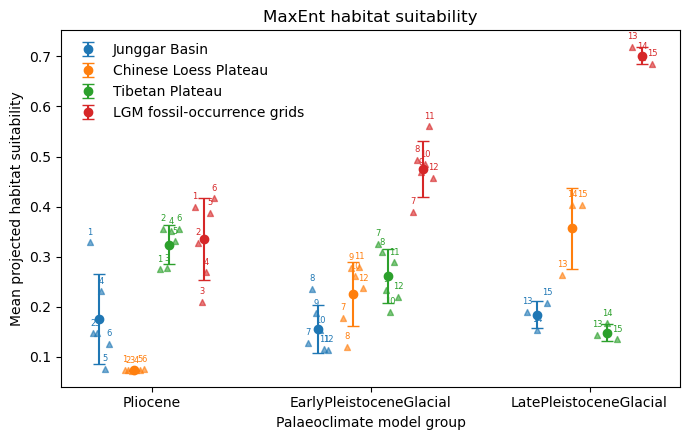

Stats: output/20000-22000_Eurasia/results/Stats/maxent_suitability_stats.xlsx
maxent_suitability: output/20000-22000_Eurasia/results/Stats/maxent_suitability_region_fossils_errorbar.png


In [15]:
analyze_suitability_stats('maxent_suitability_{model_code}.tif', maxent_output_dir, maxent_output_stats_dir, 'Mean projected habitat suitability')


## Predictor correlations


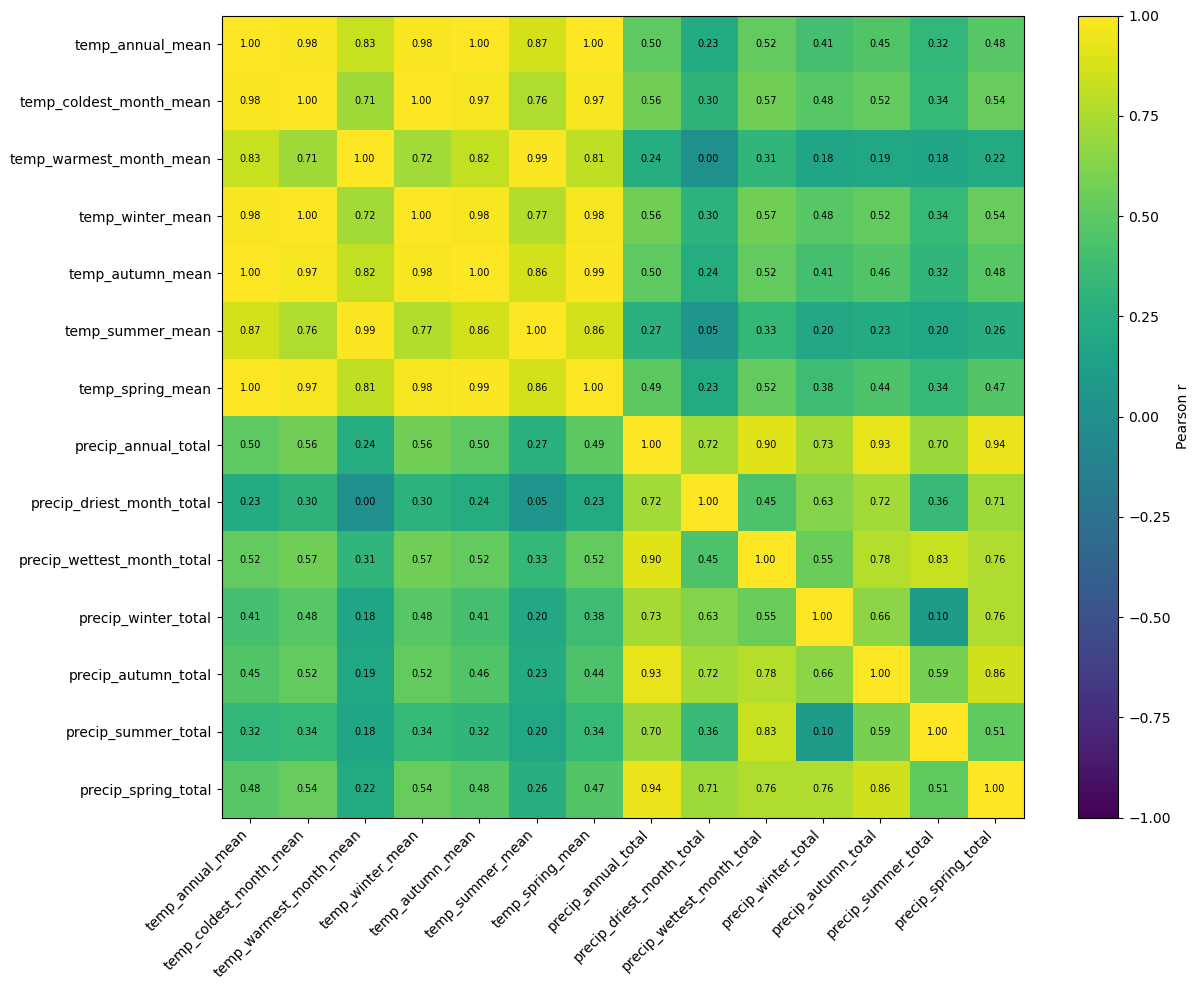

Correlation variables: 14 continuous predictors
Complete all-predictor background cells: 842
Stats: output/20000-22000_Eurasia/results/Stats/predictor_correlations_all_variables.xlsx
Figure: output/20000-22000_Eurasia/results/Stats/predictor_correlation_all_variables_pearson.png
2026-08-31 00:11:28      Runtime: 4.65 seconds


In [16]:
# Predictor correlations use all candidate continuous predictors from TRAINING_MODEL_CODE across complete-case cells in the calibration background.
# Biome is categorical and is used only in the complete-case mask, not in continuous-variable correlations.
start_time = time.time()

PREDICTOR_CORRELATION_STATS = {
    'temp': [
        'annual_mean', 'coldest_month_mean', 'warmest_month_mean',
        'winter_mean', 'autumn_mean', 'summer_mean', 'spring_mean'
    ],
    'precip': [
        'annual_total', 'driest_month_total', 'wettest_month_total',
        'winter_total', 'autumn_total', 'summer_total', 'spring_total'
    ]
}
PREDICTOR_CORRELATION_CONFIG = ['biome'] + [f'{variable_name}_{stat}' for variable_name, stats in PREDICTOR_CORRELATION_STATS.items() for stat in stats]
continuous_predictors = [p for p in PREDICTOR_CORRELATION_CONFIG if p != 'biome']

correlation_arrays = {}
for layer_name in PREDICTOR_CORRELATION_CONFIG:
    in_tif = predictor_tif_path(layer_name, TRAINING_MODEL_CODE)
    if not arcpy.Exists(in_tif):
        raise FileNotFoundError(f'Missing correlation predictor raster: {relative_path(in_tif)}')
    validate_grid_against_template(in_tif)
    raster = arcpy.Raster(in_tif)
    array = arcpy.RasterToNumPyArray(raster).astype(float)
    if raster.noDataValue is not None:
        array[np.isclose(array, float(raster.noDataValue))] = np.nan
    correlation_arrays[layer_name] = array

with arcpy.da.SearchCursor(aoi_grids_shp, ['ROW', 'COL']) as cursor:
    correlation_grid_index = pd.DataFrame(list(cursor), columns=['ROW', 'COL'])
if correlation_grid_index.empty:
    raise ValueError(f'No AOI grids in persisted file: {relative_path(aoi_grids_shp)}')

background_rows = correlation_grid_index['ROW'].to_numpy(dtype=int)
background_cols = correlation_grid_index['COL'].to_numpy(dtype=int)
correlation_background = pd.DataFrame({layer_name: array[background_rows, background_cols] for layer_name, array in correlation_arrays.items()})
full_correlation_background = correlation_background.dropna(subset=PREDICTOR_CORRELATION_CONFIG).reset_index(drop=True)
if full_correlation_background.empty:
    raise ValueError('No complete background cells across all candidate predictors')

predictor_data = full_correlation_background[continuous_predictors].apply(pd.to_numeric, errors='coerce')
pearson_corr = predictor_data.corr(method='pearson', min_periods=3)
spearman_corr = predictor_data.corr(method='spearman', min_periods=3)

pairs = []
for i, predictor1 in enumerate(continuous_predictors):
    for predictor2 in continuous_predictors[i + 1:]:
        valid_pair = predictor_data[[predictor1, predictor2]].dropna()
        pairs.append([predictor1, predictor2, len(valid_pair), pearson_corr.loc[predictor1, predictor2], spearman_corr.loc[predictor1, predictor2]])

correlation_pairs = pd.DataFrame(pairs, columns=['predictor_1', 'predictor_2', 'n_pair', 'pearson_r', 'spearman_rho'])
correlation_pairs['max_abs_correlation'] = correlation_pairs[['pearson_r', 'spearman_rho']].abs().max(axis=1)
correlation_pairs = correlation_pairs.sort_values(['max_abs_correlation', 'n_pair'], ascending=[False, False]).reset_index(drop=True)
predictor_valid_counts = pd.DataFrame({
    'predictor': PREDICTOR_CORRELATION_CONFIG,
    'background_valid_n': [correlation_background[p].notna().sum() for p in PREDICTOR_CORRELATION_CONFIG]
})
correlation_metadata = pd.DataFrame([
    ['AOI background cells', len(correlation_background)],
    ['Complete all-predictor background cells', len(full_correlation_background)],
    ['Correlation background definition', 'All candidate predictors complete-case'],
    ['Correlation source', 'Persisted AOI grid ROW/COL + predictor rasters'],
    ['Categorical predictors excluded', 'biome']
], columns=['item', 'value'])

correlation_xlsx = os.path.join(maxent_output_stats_dir, 'predictor_correlations_all_variables.xlsx')
with pd.ExcelWriter(correlation_xlsx, engine='openpyxl') as writer:
    pearson_corr.to_excel(writer, sheet_name='Pearson_continuous')
    spearman_corr.to_excel(writer, sheet_name='Spearman_continuous')
    correlation_pairs.to_excel(writer, sheet_name='continuous_pairs', index=False)
    predictor_valid_counts.to_excel(writer, sheet_name='valid_counts', index=False)
    correlation_metadata.to_excel(writer, sheet_name='metadata', index=False)
    pd.DataFrame({'predictor': PREDICTOR_CORRELATION_CONFIG}).to_excel(writer, sheet_name='predictor_config', index=False)

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(pearson_corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(continuous_predictors)))
ax.set_xticklabels(continuous_predictors, rotation=45, ha='right')
ax.set_yticks(range(len(continuous_predictors)))
ax.set_yticklabels(continuous_predictors)
for i in range(len(continuous_predictors)):
    for j in range(len(continuous_predictors)):
        ax.text(j, i, f'{pearson_corr.iloc[i, j]:.2f}', fontsize=7, ha='center', va='center')
fig.colorbar(im, ax=ax, label='Pearson r')
plt.tight_layout()
correlation_fig = os.path.join(maxent_output_stats_dir, 'predictor_correlation_all_variables_pearson.png')
correlation_pdf = os.path.join(maxent_output_stats_dir, 'predictor_correlation_all_variables_pearson.pdf')
fig.savefig(correlation_fig, dpi=300, bbox_inches='tight')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
fig.savefig(correlation_pdf, bbox_inches='tight')
plt.show()

print(f'Correlation variables: {len(continuous_predictors)} continuous predictors')
print(f'Complete all-predictor background cells: {len(full_correlation_background):,}')
print(f'Stats: {relative_path(correlation_xlsx)}')
print(f'Figure: {relative_path(correlation_fig)}')
print(f'{datetime.now():%Y-%m-%d %H:%M:%S}      Runtime: {time.time() - start_time:.2f} seconds')


## MaxEnt tuning


Running FC_L_RM_0p5 ...
Running FC_L_RM_1 ...
Running FC_L_RM_1p5 ...
Running FC_L_RM_2 ...
Running FC_L_RM_3 ...
Running FC_LQ_RM_0p5 ...
Running FC_LQ_RM_1 ...
Running FC_LQ_RM_1p5 ...
Running FC_LQ_RM_2 ...
Running FC_LQ_RM_3 ...
Running FC_LH_RM_0p5 ...
Running FC_LH_RM_1 ...
Running FC_LH_RM_1p5 ...
Running FC_LH_RM_2 ...
Running FC_LH_RM_3 ...
Running FC_LQH_RM_0p5 ...
Running FC_LQH_RM_1 ...
Running FC_LQH_RM_1p5 ...
Running FC_LQH_RM_2 ...
Running FC_LQH_RM_3 ...
2026-08-31 00:12:08      Runtime: 39.37 seconds


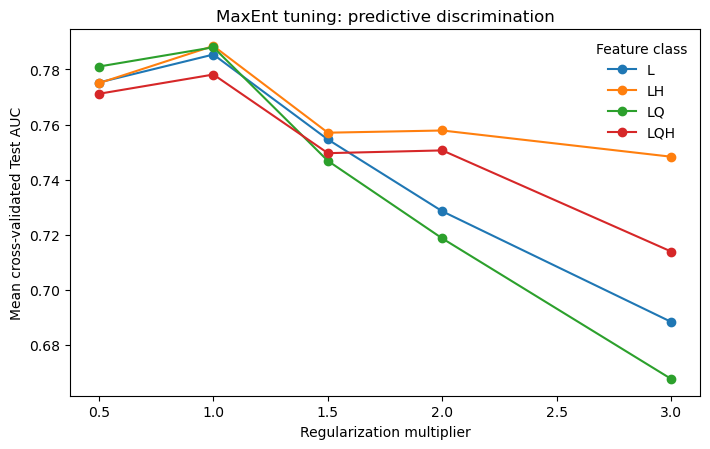

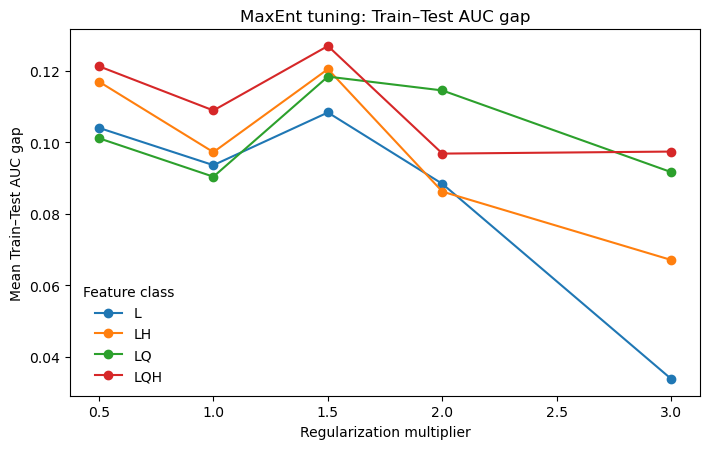

Tuning Test AUC figure: output/20000-22000_Eurasia/results/Stats/maxent_tuning_test_auc.png
Tuning AUC-gap figure: output/20000-22000_Eurasia/results/Stats/maxent_tuning_auc_gap.png


In [17]:
# MaxEnt tuning: feature classes × regularization multiplier
start_time = time.time()

TUNING_FEATURE_CONFIGS = {
    'L': {'quadratic': False, 'hinge': False, 'product': False},
    'LQ': {'quadratic': True, 'hinge': False, 'product': False},
    'LH': {'quadratic': False, 'hinge': True, 'product': False},
    'LQH': {'quadratic': True, 'hinge': True, 'product': False}
}

TUNING_RMS = [0.5, 1, 1.5, 2, 3]

tuning_dir = os.path.join(maxent_output_dir, f'Tuning_CV_{MAXENT_CV_FOLDS}fold')
os.makedirs(tuning_dir, exist_ok=True)

tuning_base_args = [
    *[arg for arg in MAXENT_BASE_ARGS if not arg.startswith('betamultiplier=')],
    f'samplesfile={fossil_grids_csv}',
    f'environmentallayers={full_background_csv}',
    *[f'togglelayertype={layer}' for layer in categorical_predictor_layers],
    'togglelayerselected=',
    *[f'togglelayerselected={layer}' for layer in configured_predictor_layers]
]

summary_rows = []
fold_tables = []

for fc, cfg in TUNING_FEATURE_CONFIGS.items():
    for rm in TUNING_RMS:
        tuning_run_name = f"FC_{fc}_RM_{str(rm).replace('.', 'p')}"
        run_dir = os.path.join(tuning_dir, tuning_run_name)
        os.makedirs(run_dir, exist_ok=True)

        tuning_feature_args = [
            'autofeature=false',
            'linear=true',
            f"quadratic={str(cfg['quadratic']).lower()}",
            f"hinge={str(cfg['hinge']).lower()}",
            f"product={str(cfg['product']).lower()}",
            'threshold=false'
        ]

        cmd = ['java', '-mx512m', '-jar', maxent_jar] + tuning_base_args + [f'betamultiplier={rm}'] + tuning_feature_args + [
            f'replicates={MAXENT_CV_FOLDS}',
            'replicatetype=crossvalidate',
            'responsecurves=false',
            'jackknife=false',
            'outputgrids=false',
            f'outputdirectory={run_dir}'
        ]

        print(f'Running {tuning_run_name} ...')
        tuning_result = subprocess.run(cmd, text=True, capture_output=True)

        if tuning_result.returncode != 0 or re.search(r'(?im)^\s*Error:', tuning_result.stderr):
            raise RuntimeError(f'MaxEnt tuning failed for {tuning_run_name}:\n{tuning_result.stderr.strip()}')

        results_csv = os.path.join(run_dir, 'maxentResults.csv')
        results = pd.read_csv(results_csv)
        folds = results[~results['Species'].str.contains('average|stddev', case=False, na=False, regex=True)].copy()

        train_auc_mean = folds['Training AUC'].mean()
        train_auc_sd = folds['Training AUC'].std()
        test_auc_mean = folds['Test AUC'].mean()
        test_auc_sd = folds['Test AUC'].std()
        auc_gap = train_auc_mean - test_auc_mean

        summary_rows.append([fc, rm, len(folds), train_auc_mean, train_auc_sd, test_auc_mean, test_auc_sd, auc_gap])

        fold_table = folds[['Species', 'Training AUC', 'Test AUC']].copy()
        fold_table.insert(0, 'RM', rm)
        fold_table.insert(0, 'feature_class', fc)
        fold_tables.append(fold_table)

tuning_summary = pd.DataFrame(summary_rows, columns=[
    'feature_class', 'RM', 'n_folds', 'train_auc_mean', 'train_auc_sd', 'test_auc_mean', 'test_auc_sd', 'auc_gap'
])

tuning_summary['current_model'] = (tuning_summary['feature_class'] == FEATURE_CLASSES) & np.isclose(tuning_summary['RM'], MAXENT_BETA_MULTIPLIER)
tuning_summary['test_auc_rank'] = tuning_summary['test_auc_mean'].rank(method='min', ascending=False).astype(int)
tuning_summary['auc_gap_rank'] = tuning_summary['auc_gap'].rank(method='min', ascending=True).astype(int)
tuning_summary = tuning_summary.sort_values(['feature_class', 'RM']).reset_index(drop=True)

tuning_folds = pd.concat(fold_tables, ignore_index=True)

tuning_metadata = pd.DataFrame([
    ['Calibration AOI', AOI_NAME],
    ['Training climate', TRAINING_MODEL_CODE],
    ['Training age range', f'{AGE_MIN}-{AGE_MAX} cal BP'],
    ['Predictors', ', '.join(configured_predictor_layers)],
    ['Categorical predictors', ', '.join(categorical_predictor_layers) if categorical_predictor_layers else 'None'],
    ['CV folds', MAXENT_CV_FOLDS],
    ['Feature classes tested', ', '.join(TUNING_FEATURE_CONFIGS)],
    ['Regularization multipliers tested', ', '.join(map(str, TUNING_RMS))],
    ['Unique training grid cells', len(pd.read_csv(fossil_grids_csv, usecols=['species']))],
    ['Training-grid SWD', relative_path(fossil_grids_csv)],
    ['Background SWD', relative_path(full_background_csv)]
], columns=['parameter', 'value'])

tuning_xlsx = os.path.join(maxent_output_stats_dir, 'maxent_tuning.xlsx')

with pd.ExcelWriter(tuning_xlsx, engine='openpyxl') as writer:
    tuning_summary.to_excel(writer, sheet_name='summary', index=False)
    tuning_folds.to_excel(writer, sheet_name='folds', index=False)
    tuning_metadata.to_excel(writer, sheet_name='metadata', index=False)

print(f'{datetime.now():%Y-%m-%d %H:%M:%S}      Runtime: {time.time() - start_time:.2f} seconds')

# Tuning diagnostic plots
# Tuning compares cross-validated Test AUC and the Train–Test AUC gap,
# favouring simpler feature-class and regularization combinations when performance is similar.
tuning_plot_data = tuning_summary.copy()

# 1. RM × cross-validated Test AUC
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for feature_class, data in tuning_plot_data.groupby('feature_class', sort=False):
    data = data.sort_values('RM')
    ax.plot(data['RM'], data['test_auc_mean'], marker='o', label=feature_class)
ax.set_xlabel('Regularization multiplier')
ax.set_ylabel('Mean cross-validated Test AUC')
ax.set_title('MaxEnt tuning: predictive discrimination')
ax.legend(title='Feature class', frameon=False)
plt.tight_layout()
tuning_auc_png = os.path.join(maxent_output_stats_dir, 'maxent_tuning_test_auc.png')
tuning_auc_pdf = os.path.join(maxent_output_stats_dir, 'maxent_tuning_test_auc.pdf')
fig.savefig(tuning_auc_png, dpi=300, bbox_inches='tight')
fig.savefig(tuning_auc_pdf, bbox_inches='tight')
plt.show()

# 2. RM × Train–Test AUC gap as a diagnostic of model complexity and potential overfitting.
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for feature_class, data in tuning_plot_data.groupby('feature_class', sort=False):
    data = data.sort_values('RM')
    ax.plot(data['RM'], data['auc_gap'], marker='o', label=feature_class)
ax.set_xlabel('Regularization multiplier')
ax.set_ylabel('Mean Train–Test AUC gap')
ax.set_title('MaxEnt tuning: Train–Test AUC gap')
ax.legend(title='Feature class', frameon=False)
plt.tight_layout()
tuning_gap_png = os.path.join(maxent_output_stats_dir, 'maxent_tuning_auc_gap.png')
tuning_gap_pdf = os.path.join(maxent_output_stats_dir, 'maxent_tuning_auc_gap.pdf')
fig.savefig(tuning_gap_png, dpi=300, bbox_inches='tight')
fig.savefig(tuning_gap_pdf, bbox_inches='tight')
plt.show()

print(f'Tuning Test AUC figure: {relative_path(tuning_auc_png)}')
print(f'Tuning AUC-gap figure: {relative_path(tuning_gap_png)}')
